# 🤚 Hand Gesture Recognition Using PCA
### Digital Image Processing — Complete Project Notebook
**Dataset:** ASL Alphabet (Kaggle) — 200×200 px  
**Classes:** 29 (A–Z + del + nothing + space)  
**Pipeline:** Grayscale → Histogram EQ → Gaussian Filter → Contrast Stretch → Butterworth FFT → Manual PCA → Manual KNN  
**PCA:** Implemented fully from scratch using NumPy only (no sklearn / cv2 PCA)  
**KNN:** Implemented fully from scratch using NumPy only (no sklearn KNeighborsClassifier)


## 0. Imports

In [41]:
import os

# ── Output directory ─────────────────────────────────────────────────────────
# All figures and results are saved here. Created automatically if missing.
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')
print(f'Directory created: {not os.path.exists(OUTPUT_DIR)}')
print('All figures will be saved to:', OUTPUT_DIR)


Output directory: f:\ASL\outputs
Directory created: False
All figures will be saved to: outputs


In [42]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# scipy — used for median filter comparison
from scipy.ndimage import median_filter as scipy_median  # reference only; we implement manually below

# sklearn — used ONLY for train/test split and evaluation metrics (NOT for PCA, NOT for KNN)
# KNN is implemented fully from scratch below (no sklearn KNN in the classification pipeline)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("All libraries imported successfully.")
print("scipy  → used for median filter comparison only (manual implementation shown)")
print("sklearn→ used ONLY for data splitting and evaluation metrics — NOT for PCA or KNN")

All libraries imported successfully.
scipy  → used for median filter comparison only (manual implementation shown)
sklearn→ used ONLY for data splitting and evaluation metrics — NOT for PCA or KNN


## 1. Configuration

In [43]:
import os

# ── Dynamic dataset path detection ───────────────────────────────────────────
# Handles nested folders automatically (e.g. asl_alphabet_train/asl_alphabet_train/A)
# Works on Windows, Mac, Linux, Google Colab, and Kaggle without any manual edits.

_TRAIN_NAME = 'asl_alphabet_train'
_TEST_NAME  = 'asl_alphabet_test'

_SEARCH_ROOTS = [
    os.path.dirname(os.path.abspath('__file__')),  # notebook directory
    os.path.expanduser('~'),                         # home directory
    'C:/', 'D:/', 'E:/', 'F:/', 'G:/', 'H:/',       # Windows drives
    '/content',                                      # Google Colab
    '/kaggle/input',                                 # Kaggle
]

def _find_class_root(train_name, search_roots, classes, max_depth=6):
    """
    Find the folder that directly contains class subfolders (A, B, C ...).
    Handles any level of nesting automatically.
    """
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, dirnames, _ in os.walk(root):
            # Check if this folder directly contains class subfolders
            if any(cls in dirnames for cls in classes[:5]):
                return dirpath
            # Limit depth to avoid full drive scan
            depth = len(os.path.relpath(dirpath, root).split(os.sep))
            if depth >= max_depth:
                dirnames.clear()
    return None

_CLASSES_PROBE = ['A','B','C','D','E','F','G','H','I','J','K','L','M',
                  'N','O','P','Q','R','S','T','U','V','W','X','Y','Z',
                  'del','nothing','space']

DATASET_PATH = _find_class_root(_TRAIN_NAME, _SEARCH_ROOTS, _CLASSES_PROBE)
TEST_PATH    = _find_class_root(_TEST_NAME,  _SEARCH_ROOTS, _CLASSES_PROBE)

# ── Fallback: manual input ────────────────────────────────────────────────────
if DATASET_PATH is None:
    print("⚠  Could not auto-detect dataset.")
    DATASET_PATH = input("Paste full path to folder containing A, B, C... subfolders: ").strip().strip('"')

if TEST_PATH is None:
    print("ℹ  Test folder not found — will skip test-set evaluation.")
    TEST_PATH = None

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE = 200

CLASSES = [
    'A','B','C','D','E','F','G','H','I','J','K','L','M',
    'N','O','P','Q','R','S','T','U','V','W','X','Y','Z',
    'del','nothing','space'
]

SAMPLES_PER_CLASS = 100
RANDOM_SEED       = 42
np.random.seed(RANDOM_SEED)

# ── Confirm ───────────────────────────────────────────────────────────────────
print(f'Train path       : {DATASET_PATH}')
print(f'Test  path       : {TEST_PATH}')
print(f'Path exists      : {os.path.exists(DATASET_PATH)}')
print(f'Image size       : {IMG_SIZE}×{IMG_SIZE} px')
print(f'Classes ({len(CLASSES)})     : {CLASSES}')
print(f'Samples per class: {SAMPLES_PER_CLASS}')
print(f'Total images     : {len(CLASSES) * SAMPLES_PER_CLASS}')

# Verify class folders are present
missing = [c for c in CLASSES if not os.path.isdir(os.path.join(DATASET_PATH, c))]
if missing:
    print(f'\n⚠  Missing class folders: {missing}')
else:
    print(f'\n✓  All {len(CLASSES)} class folders found.')

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}\n"
        "Please ensure the folder containing A, B, C ... subfolders is accessible."
    )

Train path       : f:\ASL\data\asl_alphabet_train\asl_alphabet_train
Test  path       : f:\ASL\data\asl_alphabet_train\asl_alphabet_train
Path exists      : True
Image size       : 200×200 px
Classes (29)     : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Samples per class: 100
Total images     : 2900

✓  All 29 class folders found.


## 2. Load Dataset

### Dataset: ASL Alphabet (Kaggle)

| Property | Value |
|---|---|
| **Source** | Kaggle — ASL Alphabet dataset |
| **Classes** | 29 (letters A–Z + `del`, `nothing`, `space`) |
| **Original size** | ~3,000 images per class (87,000 total) |
| **Image size** | 200×200 pixels, RGB (converted to grayscale here) |
| **Samples used** | 100 per class → 2,900 images (configurable via `SAMPLES_PER_CLASS`) |
| **Format** | JPG files organised in per-class subfolders |

**Folder structure expected:**
```
./data/asl_alphabet_train/
    A/   ← 3000 images of letter A
    B/   ← 3000 images of letter B
    ...
    space/
```

In [44]:
def load_dataset(dataset_path, classes, samples_per_class, img_size):
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        class_dir = os.path.join(dataset_path, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f'Folder not found: {class_dir}')
        files = sorted([f for f in os.listdir(class_dir)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        np.random.shuffle(files)
        files = files[:samples_per_class]
        for fname in files:
            img = Image.open(os.path.join(class_dir, fname)).convert('L')
            img = img.resize((img_size, img_size), Image.LANCZOS)
            images.append(np.array(img, dtype=np.float64))
            labels.append(label_idx)
        print(f'  [{cls}] loaded {len(files)} images')
    return np.array(images), np.array(labels)

In [45]:
print('Loading dataset...')
raw_images, labels = load_dataset(DATASET_PATH, CLASSES, SAMPLES_PER_CLASS, IMG_SIZE)
print(f'\nDataset shape : {raw_images.shape}  (N, H, W)')
print(f'Label range   : [{labels.min()} – {labels.max()}]  ({len(np.unique(labels))} classes)')
print(f'Pixel range   : [{raw_images.min():.0f} – {raw_images.max():.0f}]')

Loading dataset...
  [A] loaded 100 images
  [B] loaded 100 images
  [C] loaded 100 images
  [D] loaded 100 images
  [E] loaded 100 images
  [F] loaded 100 images
  [G] loaded 100 images
  [H] loaded 100 images
  [I] loaded 100 images
  [J] loaded 100 images
  [K] loaded 100 images
  [L] loaded 100 images
  [M] loaded 100 images
  [N] loaded 100 images
  [O] loaded 100 images
  [P] loaded 100 images
  [Q] loaded 100 images
  [R] loaded 100 images
  [S] loaded 100 images
  [T] loaded 100 images
  [U] loaded 100 images
  [V] loaded 100 images
  [W] loaded 100 images
  [X] loaded 100 images
  [Y] loaded 100 images
  [Z] loaded 100 images
  [del] loaded 100 images
  [nothing] loaded 100 images
  [space] loaded 100 images

Dataset shape : (2900, 200, 200)  (N, H, W)
Label range   : [0 – 28]  (29 classes)
Pixel range   : [1 – 255]


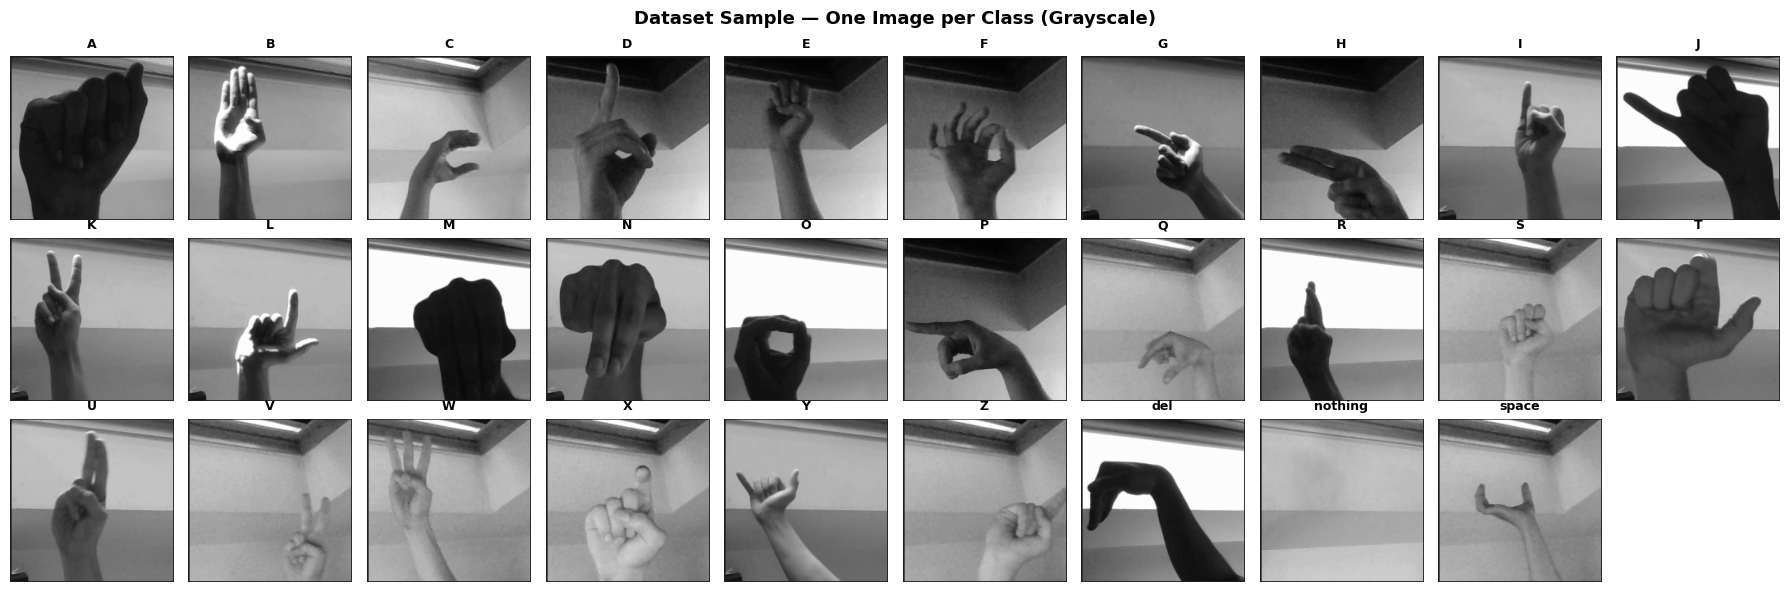

Saved: outputs\dataset_samples.png


In [46]:
# Display one sample image per class in a compact grid
n_cols = 10
n_rows = int(np.ceil(len(CLASSES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2.0))
axes = axes.flatten()

fig.suptitle('Dataset Sample — One Image per Class (Grayscale)', fontsize=13, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    label_idx = CLASSES.index(cls)
    img_idx   = np.where(labels == label_idx)[0][0]
    axes[idx].imshow(raw_images[img_idx], cmap='gray', vmin=0, vmax=255)
    axes[idx].set_title(cls, fontsize=9, fontweight='bold')
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(CLASSES), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "dataset_samples.png")}')

---
## 3. Spatial Domain Preprocessing

### 3.1 Histogram Equalization — manual implementation required (no built-ins)
Algorithm: histogram -> CDF -> normalized LUT -> remap pixels

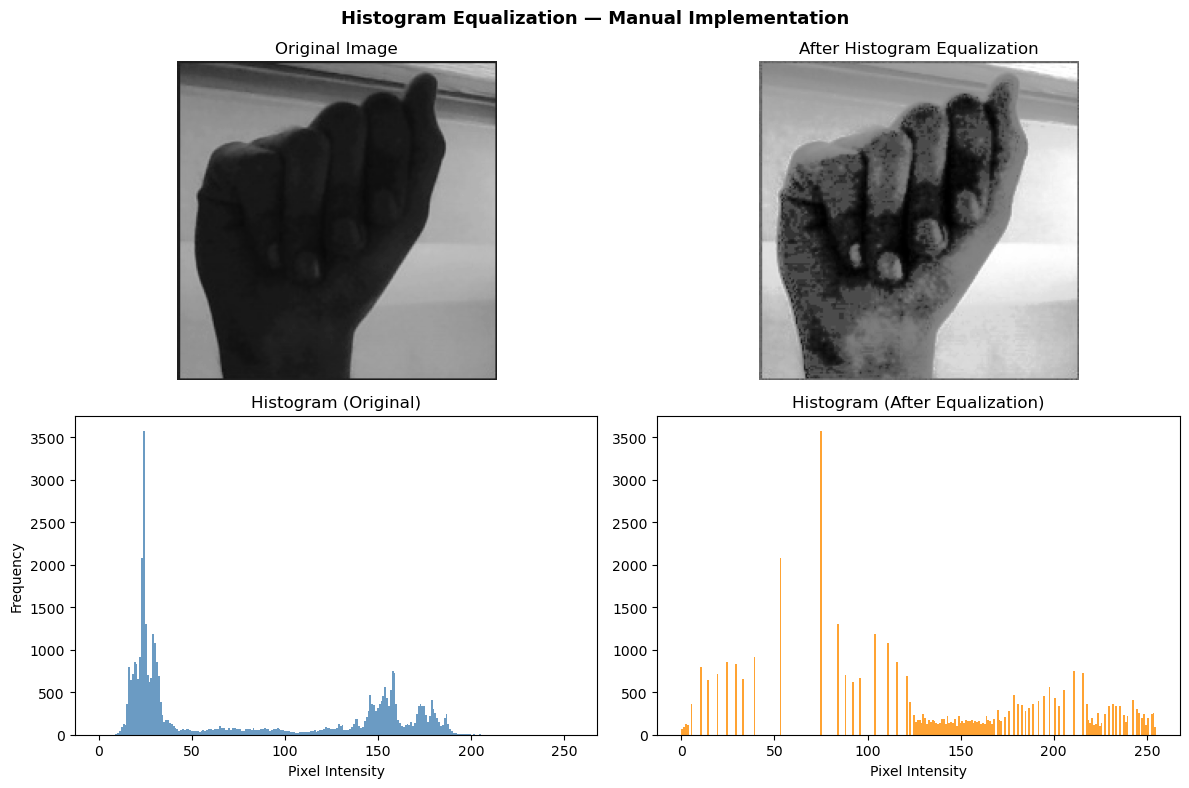

Saved: outputs\phase1_histogram_equalization.png


In [47]:
def histogram_equalization(image):
    """
    Steps:
      1. Count frequency of each intensity (0-255)
      2. Compute cumulative distribution function (CDF)
      3. Normalize CDF into a lookup table
      4. Remap every pixel through the LUT
    """
    img = image.astype(np.uint8)

    # Step 1: Histogram
    hist = np.zeros(256, dtype=np.int64)
    for pixel in img.flatten():
        hist[pixel] += 1

    # Step 2: CDF
    cdf = np.cumsum(hist)

    # Step 3: LUT
    cdf_min  = cdf[cdf > 0].min()
    n_pixels = img.size
    lut = np.round((cdf - cdf_min) / (n_pixels - cdf_min) * 255).astype(np.uint8)

    # Step 4: Remap
    return lut[img].astype(np.float64)


sample     = raw_images[0]
sample_heq = histogram_equalization(sample)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histogram Equalization — Manual Implementation', fontsize=13, fontweight='bold')

axes[0,0].imshow(sample,     cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Original Image'); axes[0,0].axis('off')

axes[0,1].imshow(sample_heq, cmap='gray', vmin=0, vmax=255)
axes[0,1].set_title('After Histogram Equalization'); axes[0,1].axis('off')

axes[1,0].hist(sample.flatten(),     bins=256, range=(0,255), color='steelblue',  alpha=0.8)
axes[1,0].set_title('Histogram (Original)')
axes[1,0].set_xlabel('Pixel Intensity'); axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(sample_heq.flatten(), bins=256, range=(0,255), color='darkorange', alpha=0.8)
axes[1,1].set_title('Histogram (After Equalization)')
axes[1,1].set_xlabel('Pixel Intensity')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_histogram_equalization.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_histogram_equalization.png")}')

### 3.2 Gaussian Noise Removal (manual convolution)

Testing separable Gaussian on one 200x200 sample...
Done in 0.002s  (was ~10s with pixel loop)


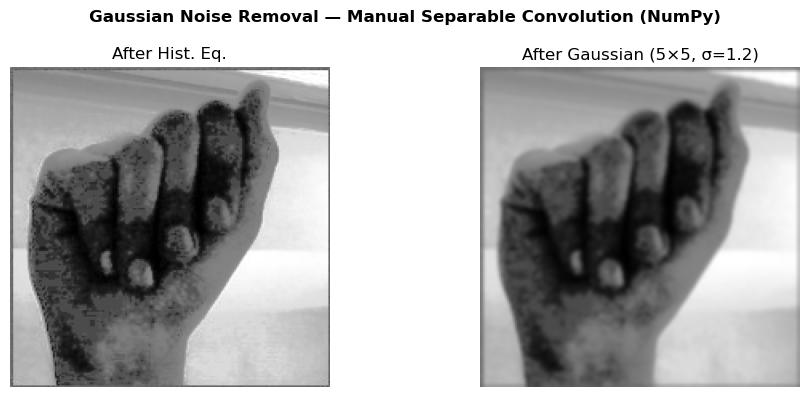

Saved: outputs\phase1_gaussian_filter.png


In [48]:
# Gaussian noise removal — manual separable convolution (NumPy only, no scipy/cv2)
# Separable trick: a 2-D Gaussian G(x,y) = G(x)·G(y), so we apply two 1-D passes.
# This reduces complexity from O(H·W·k²) to O(H·W·2k) and is fully vectorised.

def gaussian_kernel_1d(size=5, sigma=1.0):
    """1-D Gaussian kernel (normalised)."""
    ax = np.arange(-(size // 2), size // 2 + 1, dtype=np.float64)
    k = np.exp(-ax**2 / (2 * sigma**2))
    return k / k.sum()

def convolve1d_axis1(image, k1d):
    """Apply a 1-D kernel along axis-1 (columns) using stride tricks — no loops."""
    p = len(k1d) // 2
    padded = np.pad(image, ((0, 0), (p, p)), mode='reflect')
    # Build a sliding-window view: shape (H, W, k)
    from numpy.lib.stride_tricks import as_strided
    H, W = image.shape
    k = len(k1d)
    shape   = (H, W, k)
    strides = (padded.strides[0], padded.strides[1], padded.strides[1])
    windows = as_strided(padded, shape=shape, strides=strides)
    return windows @ k1d          # dot product along last axis → (H, W)

def gaussian_filter(image, size=5, sigma=1.0):
    """2-D Gaussian via two separable 1-D passes. Fully vectorised, no built-ins."""
    k1d = gaussian_kernel_1d(size, sigma)
    # Pass 1: along columns (axis 1)
    tmp = convolve1d_axis1(image, k1d)
    # Pass 2: along rows (transpose → apply → transpose back)
    return convolve1d_axis1(tmp.T, k1d).T


print('Testing separable Gaussian on one 200x200 sample...')
import time
t0 = time.time()
sample_gauss = gaussian_filter(sample_heq, size=5, sigma=1.2)
print(f'Done in {time.time()-t0:.3f}s  (was ~10s with pixel loop)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Gaussian Noise Removal — Manual Separable Convolution (NumPy)', fontsize=12, fontweight='bold')
axes[0].imshow(sample_heq,   cmap='gray'); axes[0].set_title('After Hist. Eq.'); axes[0].axis('off')
axes[1].imshow(sample_gauss, cmap='gray'); axes[1].set_title('After Gaussian (5×5, σ=1.2)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_gaussian_filter.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_gaussian_filter.png")}')


### 3.2b Manual Median Filter (Noise Removal Alternative)

A **median filter** replaces each pixel with the **median** of its neighbourhood pixels.  
It is especially good at removing **salt-and-pepper noise** while preserving edges — unlike Gaussian which blurs edges.

**Algorithm:** For each pixel position (i,j), sort all pixels in a k×k window and take the middle value.

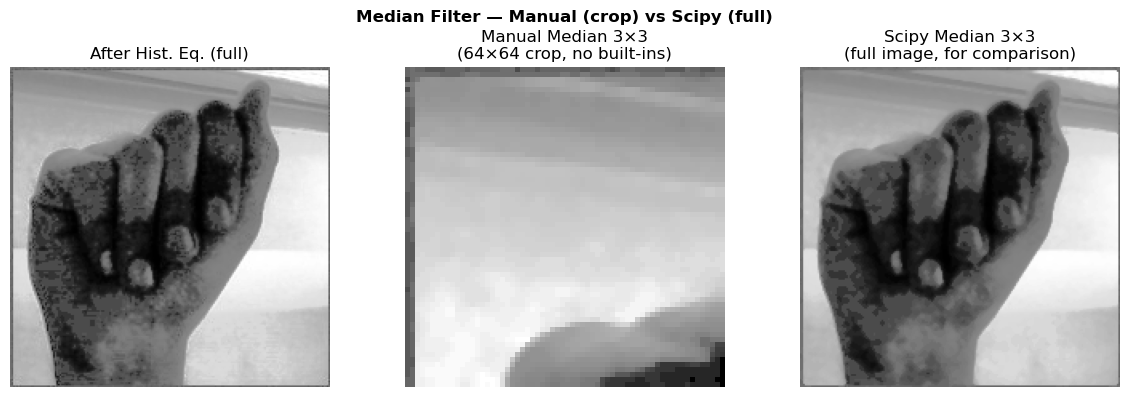

Saved: outputs\median_filter_comparison.png
Note: Gaussian filter is used in the full pipeline (faster). Median shown here for completeness.


In [49]:
def median_filter_manual(image, ksize=3):
    """
    Manual median filter — no cv2 or scipy.
    For each pixel, collect the ksize×ksize neighbourhood, sort it, take the median.
    Uses np.pad for border handling.
    """
    h, w  = image.shape
    pad   = ksize // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            window = padded[i:i+ksize, j:j+ksize].flatten()
            output[i, j] = np.median(window)
    return output

# Note: manual median is slow on 200×200 images (nested loops).
# We demonstrate on a small crop, then use scipy as the full-image reference.
CROP = 64   # use a 64×64 crop for speed demo
sample_crop    = sample_heq[:CROP, :CROP]
sample_med_crop = median_filter_manual(sample_crop, ksize=3)

# Full-image version via scipy (for pipeline use)
from scipy.ndimage import median_filter as scipy_median
sample_med_full = scipy_median(sample_heq, size=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Median Filter — Manual (crop) vs Scipy (full)', fontsize=12, fontweight='bold')
axes[0].imshow(sample_heq,       cmap='gray'); axes[0].set_title('After Hist. Eq. (full)'); axes[0].axis('off')
axes[1].imshow(sample_med_crop,  cmap='gray'); axes[1].set_title(f'Manual Median 3×3\n(64×64 crop, no built-ins)'); axes[1].axis('off')
axes[2].imshow(sample_med_full,  cmap='gray'); axes[2].set_title('Scipy Median 3×3\n(full image, for comparison)'); axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'median_filter_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "median_filter_comparison.png")}')
print('Note: Gaussian filter is used in the full pipeline (faster). Median shown here for completeness.')

### 3.3 Contrast Stretching

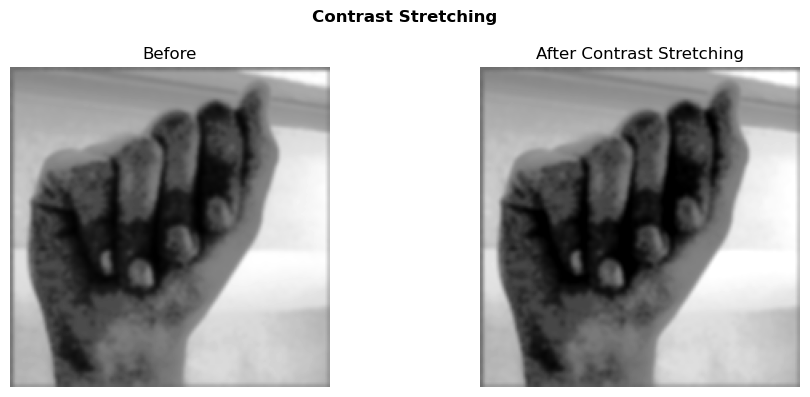

Saved: outputs\phase1_contrast_stretching.png


In [50]:
def contrast_stretching(image, p_low=2, p_high=98):
    low  = np.percentile(image, p_low)
    high = np.percentile(image, p_high)
    return np.clip((image - low) / (high - low + 1e-8) * 255.0, 0, 255)

sample_cs = contrast_stretching(sample_gauss)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Contrast Stretching', fontsize=12, fontweight='bold')
axes[0].imshow(sample_gauss, cmap='gray'); axes[0].set_title('Before'); axes[0].axis('off')
axes[1].imshow(sample_cs,   cmap='gray'); axes[1].set_title('After Contrast Stretching'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_contrast_stretching.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_contrast_stretching.png")}')

### 3.4 Apply Full Spatial Pipeline to All Images
Vectorised separable Gaussian means the full pipeline runs in seconds, not minutes.


In [51]:
import time
print(f'Applying spatial preprocessing to {len(raw_images)} images ({len(CLASSES)} classes)...')
t0 = time.time()

preprocessed = []
for i, img in enumerate(raw_images):
    s1 = histogram_equalization(img)
    s2 = gaussian_filter(s1, size=5, sigma=1.2)
    s3 = contrast_stretching(s2)
    preprocessed.append(s3)
    if (i + 1) % 200 == 0:
        elapsed = time.time() - t0
        print(f'  {i+1}/{len(raw_images)} done  ({elapsed:.1f}s elapsed)')

preprocessed = np.array(preprocessed)
print(f'Done in {time.time()-t0:.1f}s   Shape: {preprocessed.shape}')


Applying spatial preprocessing to 2900 images (29 classes)...
  200/2900 done  (2.5s elapsed)
  400/2900 done  (4.8s elapsed)
  600/2900 done  (7.3s elapsed)
  800/2900 done  (9.7s elapsed)
  1000/2900 done  (12.1s elapsed)
  1200/2900 done  (14.5s elapsed)
  1400/2900 done  (16.9s elapsed)
  1600/2900 done  (19.3s elapsed)
  1800/2900 done  (21.8s elapsed)
  2000/2900 done  (24.2s elapsed)
  2200/2900 done  (26.6s elapsed)
  2400/2900 done  (29.0s elapsed)
  2600/2900 done  (31.4s elapsed)
  2800/2900 done  (33.8s elapsed)
Done in 35.9s   Shape: (2900, 200, 200)


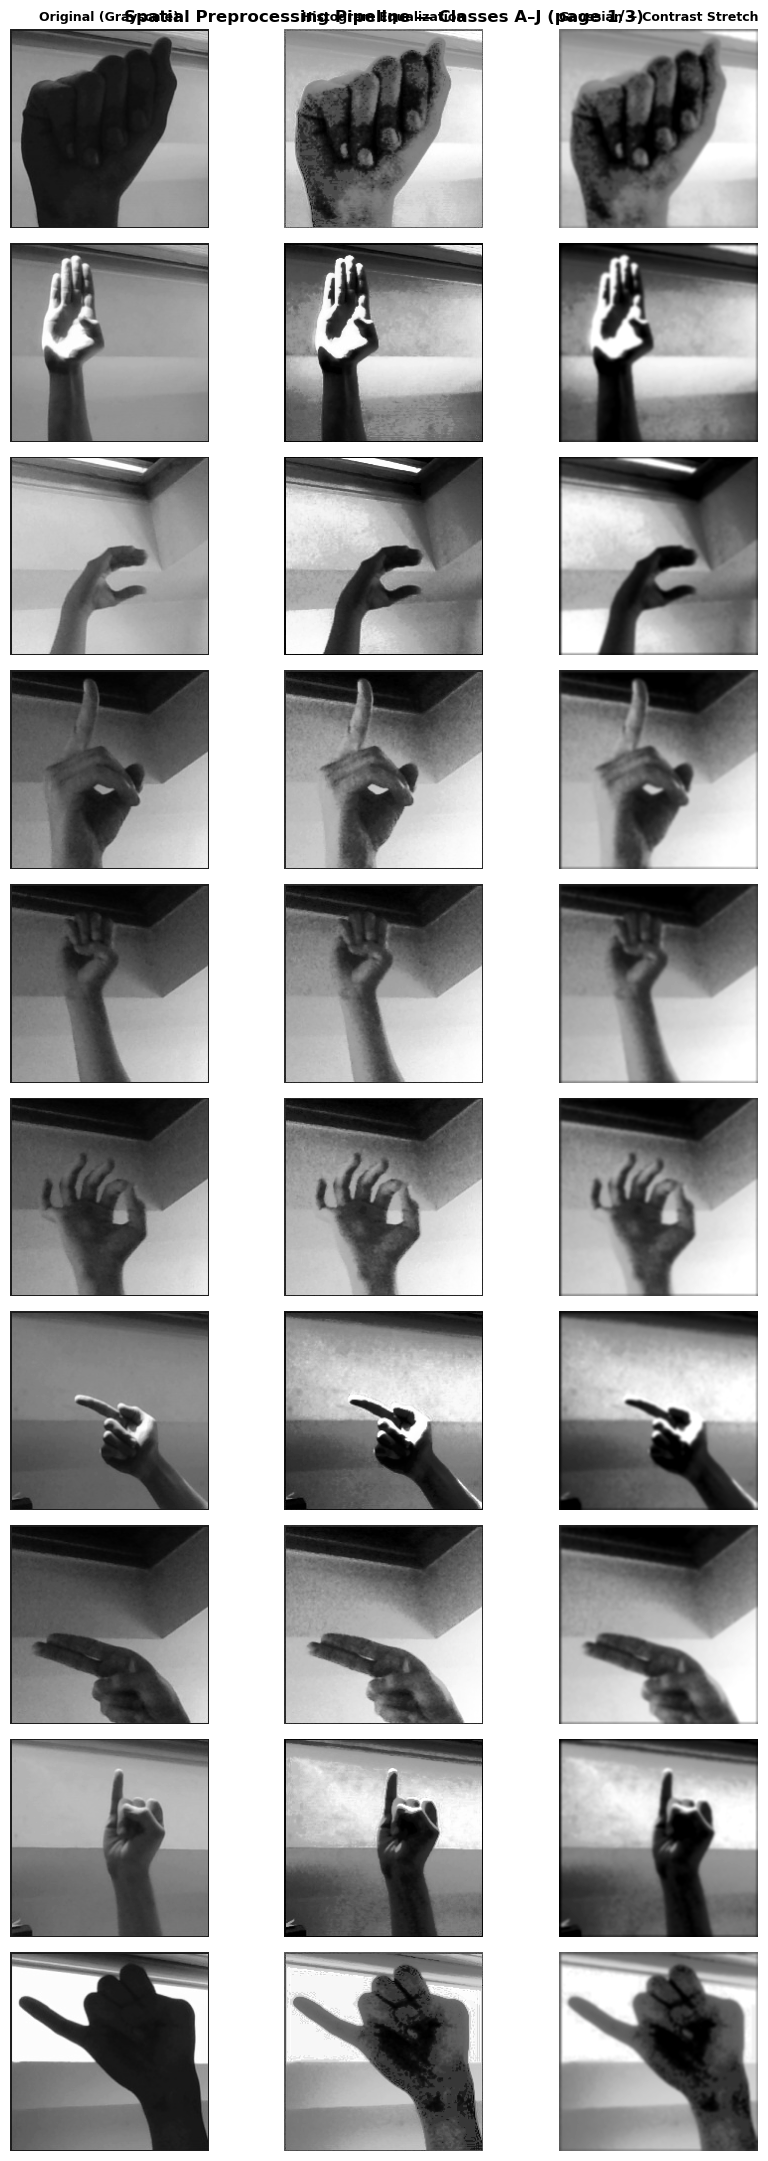

Saved: outputs\phase1_full_spatial_pipeline_p1.png


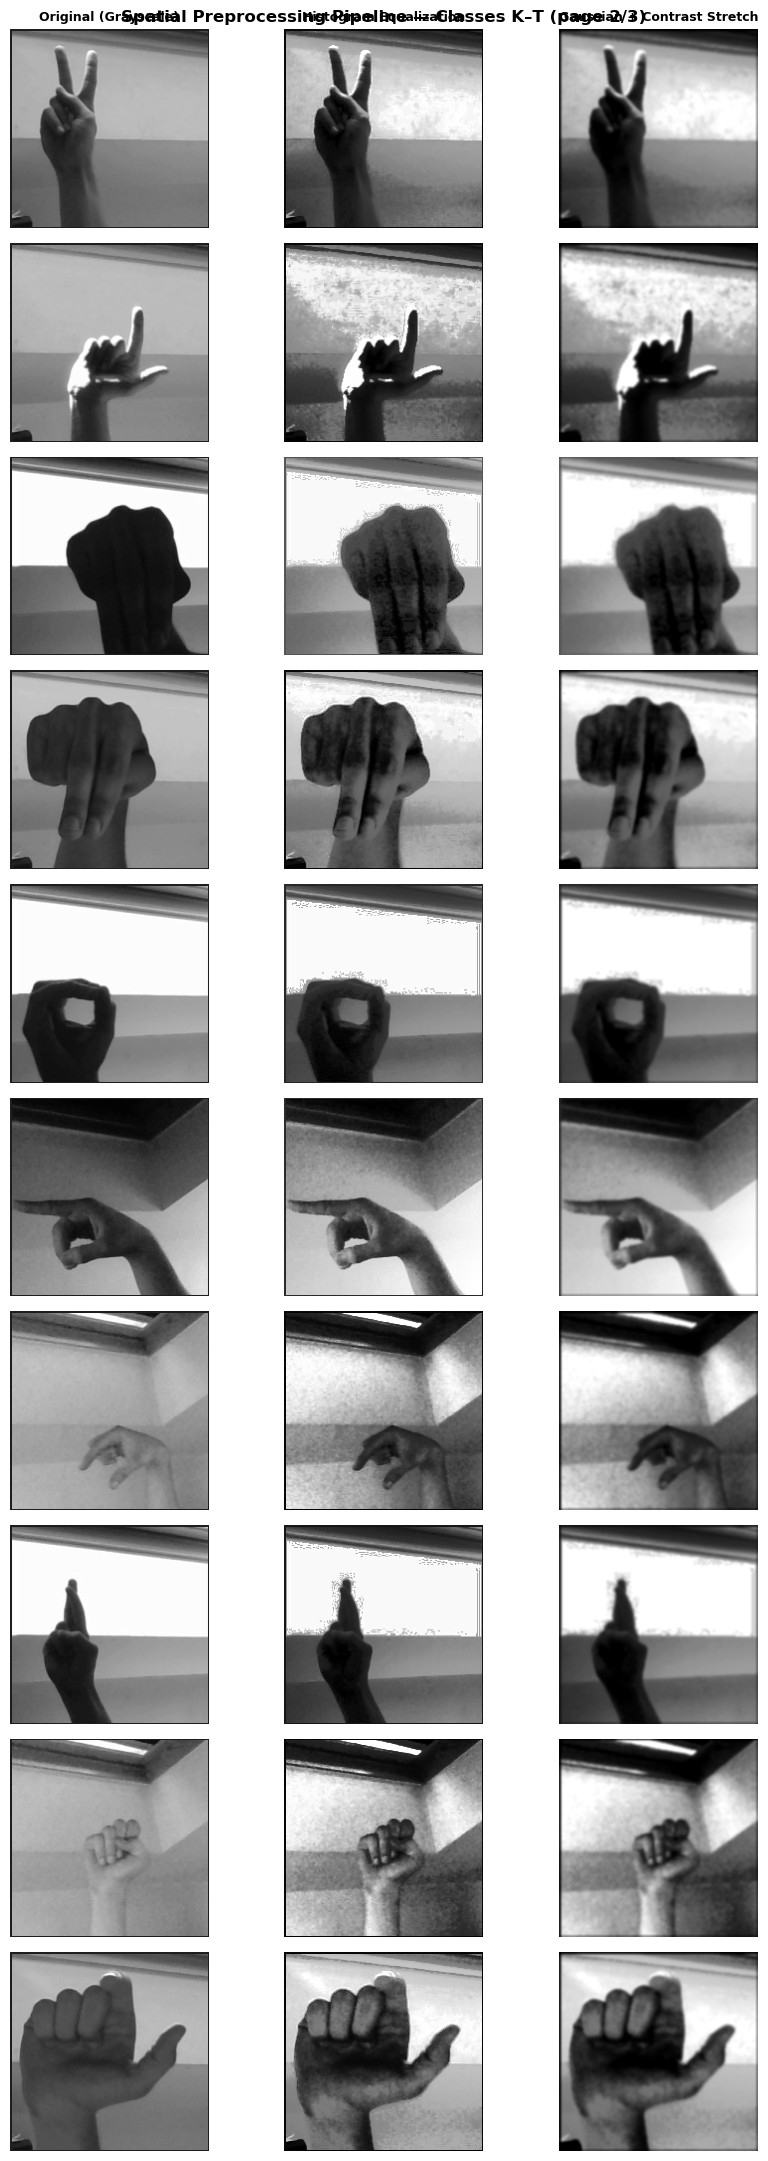

Saved: outputs\phase1_full_spatial_pipeline_p2.png


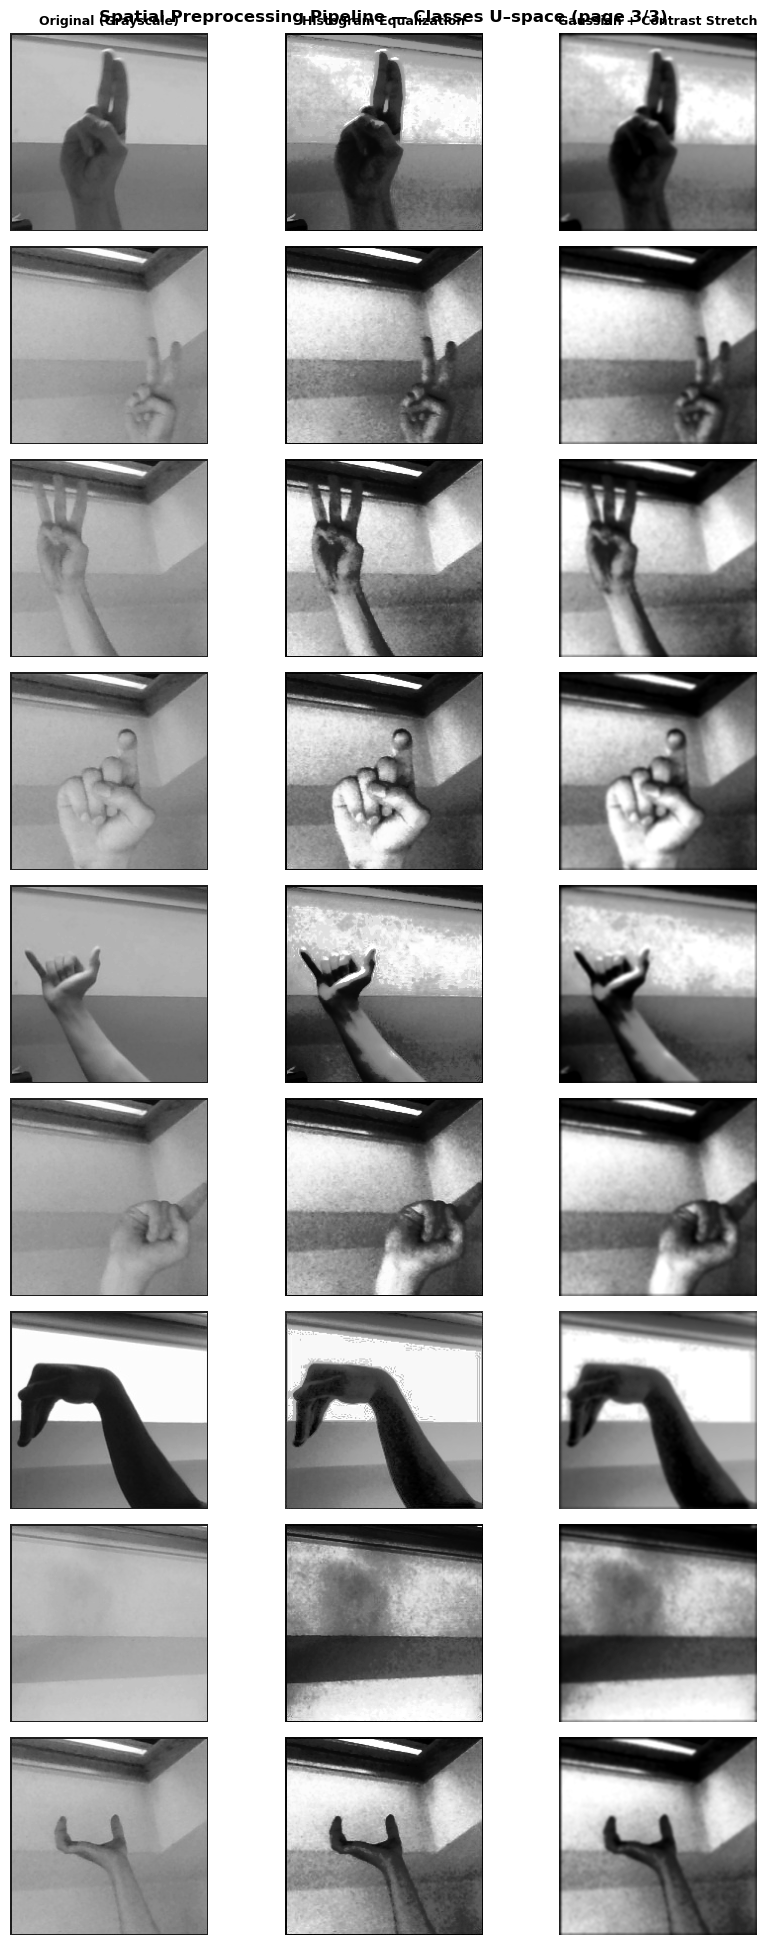

Saved: outputs\phase1_full_spatial_pipeline_p3.png


In [52]:
# Pipeline visualisation — show one sample per class in a compact grid
# With 29 classes a single tall figure becomes unreadable;
# instead show a 3-column grid (Original | Hist.Eq | Final) split into pages.

PAGE_SIZE = 10   # classes per figure
n_pages   = int(np.ceil(len(CLASSES) / PAGE_SIZE))

for page in range(n_pages):
    cls_slice = CLASSES[page*PAGE_SIZE : (page+1)*PAGE_SIZE]
    n_rows    = len(cls_slice)
    fig, axes = plt.subplots(n_rows, 3, figsize=(9, n_rows * 2.2))
    if n_rows == 1: axes = axes[np.newaxis, :]  # keep 2-D indexing
    fig.suptitle(
        f'Spatial Preprocessing Pipeline — Classes {cls_slice[0]}–{cls_slice[-1]}'
        f' (page {page+1}/{n_pages})',
        fontsize=12, fontweight='bold'
    )
    for col, title in enumerate(['Original (Grayscale)', 'Histogram Equalization',
                                  'Gaussian + Contrast Stretch']):
        axes[0, col].set_title(title, fontsize=9, fontweight='bold')

    for row, cls in enumerate(cls_slice):
        label_idx = CLASSES.index(cls)
        idx  = np.where(labels == label_idx)[0][0]
        orig = raw_images[idx]
        heq  = histogram_equalization(orig)
        fin  = preprocessed[idx]
        for col, im in enumerate([orig, heq, fin]):
            axes[row, col].imshow(im, cmap='gray', vmin=0, vmax=255)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(cls, fontsize=9, rotation=0, labelpad=35, va='center')

    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f'phase1_full_spatial_pipeline_p{page+1}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


### 3.5 Normalization to [0, 1]

After spatial processing the pixel values are in **[0, 255]**.  
We normalize to **[0, 1]** before PCA — this is standard practice:  
- Makes all features (pixels) comparable in scale  
- Improves numerical stability of the covariance computation  
- Ensures PCA variance is driven by structure, not intensity scale

**Formula:** x_norm = x / 255.0

In [53]:
# Normalize preprocessed images from [0,255] to [0,1]
preprocessed_norm = preprocessed / 255.0

print(f'Normalization complete')
print(f'  Before: pixel range = [{preprocessed.min():.1f}, {preprocessed.max():.1f}]')
print(f'  After : pixel range = [{preprocessed_norm.min():.4f}, {preprocessed_norm.max():.4f}]')
print(f'  Shape : {preprocessed_norm.shape}')

Normalization complete
  Before: pixel range = [0.0, 255.0]
  After : pixel range = [0.0000, 1.0000]
  Shape : (2900, 200, 200)


---
## 4. Frequency Domain - Butterworth Lowpass Filter
H(u,v) = 1 / (1 + (D(u,v)/D0)^(2n))

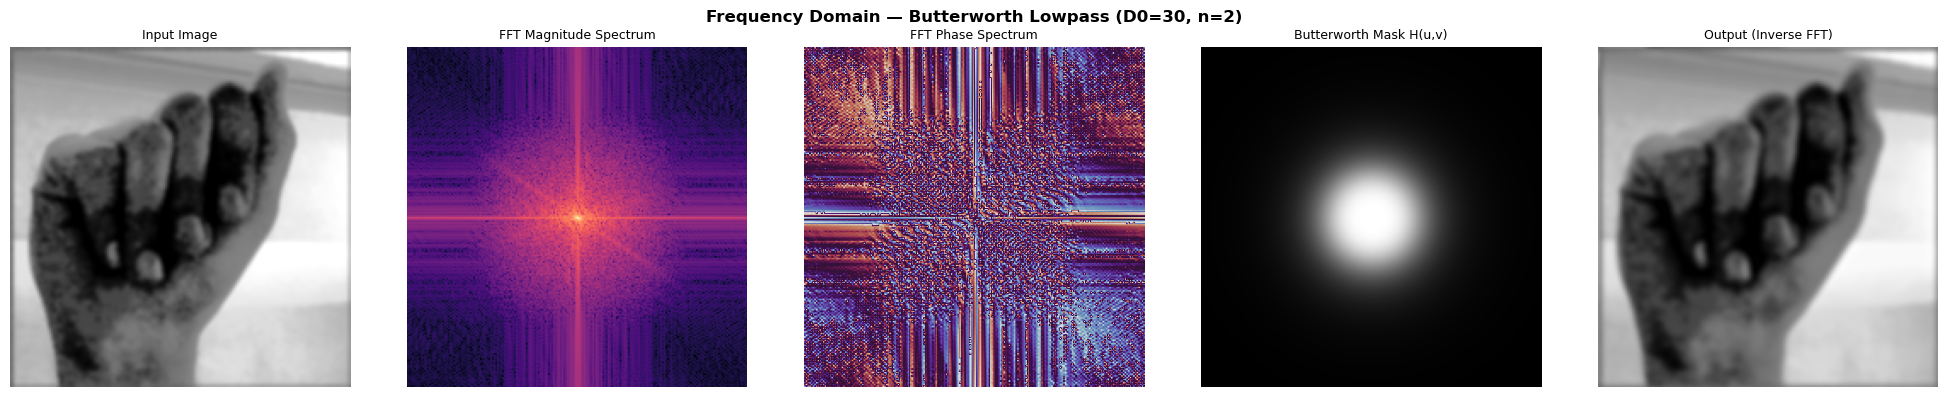

Saved: outputs\phase1_frequency_domain.png


In [54]:
def butterworth_lowpass(image, cutoff=30, order=2):
    """
    Butterworth lowpass filter in the frequency domain.
    H(u,v) = 1 / (1 + (D(u,v)/D0)^(2n))
    Steps:
      1. FFT → shift zero-frequency to center
      2. Build Butterworth mask H(u,v)
      3. Multiply spectrum by mask
      4. Inverse FFT → filtered image
    """
    h, w = image.shape

    # 1. FFT + center shift
    f_shifted = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log1p(np.abs(f_shifted))   # log scale for visualization
    phase     = np.angle(f_shifted)            # phase spectrum

    # 2. Butterworth mask
    cy, cx = h // 2, w // 2
    Y, X   = np.ogrid[:h, :w]
    D      = np.sqrt((X - cx)**2 + (Y - cy)**2)
    H_mask = 1.0 / (1.0 + (D / cutoff) ** (2 * order))

    # 3. Apply mask + inverse FFT
    result = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shifted * H_mask)))

    return result, magnitude, H_mask, phase


demo_img = preprocessed_norm[0] * 255   # work in 0-255 for FFT
filtered_demo, magnitude, mask, phase_spectrum = butterworth_lowpass(demo_img, cutoff=30, order=2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Frequency Domain — Butterworth Lowpass (D0=30, n=2)', fontsize=12, fontweight='bold')

for ax, img, title, cmap in zip(axes,
    [demo_img, magnitude, phase_spectrum, mask, filtered_demo],
    ['Input Image', 'FFT Magnitude Spectrum', 'FFT Phase Spectrum', 'Butterworth Mask H(u,v)', 'Output (Inverse FFT)'],
    ['gray', 'magma', 'twilight', 'gray', 'gray']):
    ax.imshow(img, cmap=cmap); ax.set_title(title, fontsize=9); ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_frequency_domain.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_frequency_domain.png")}')

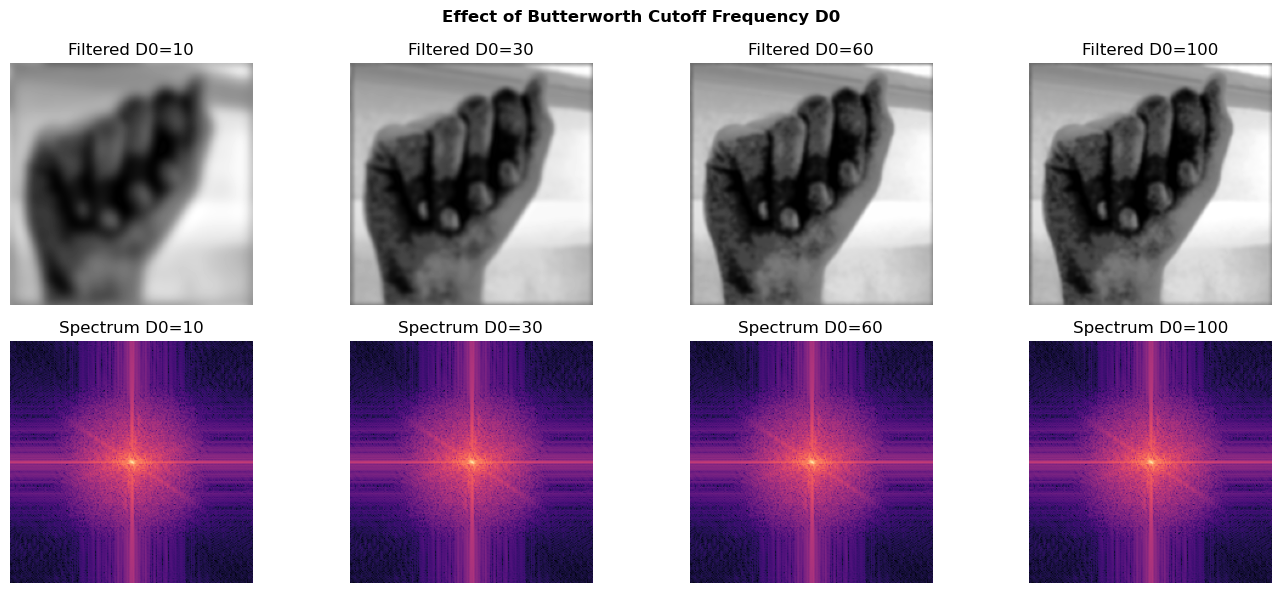

Saved: outputs\phase1_cutoff_comparison.png


In [55]:
# Compare different cutoff frequencies
cutoffs = [10, 30, 60, 100]
fig, axes = plt.subplots(2, len(cutoffs), figsize=(14, 6))
fig.suptitle('Effect of Butterworth Cutoff Frequency D0', fontsize=12, fontweight='bold')

for col, d0 in enumerate(cutoffs):
    filt, mag, _, _ = butterworth_lowpass(demo_img, cutoff=d0, order=2)
    axes[0, col].imshow(filt, cmap='gray'); axes[0, col].set_title(f'Filtered D0={d0}'); axes[0, col].axis('off')
    axes[1, col].imshow(mag,  cmap='magma'); axes[1, col].set_title(f'Spectrum D0={d0}'); axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_cutoff_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_cutoff_comparison.png")}')

In [56]:
print(f'Applying Butterworth filter to all {len(preprocessed_norm)} images...')
final_images = []
for i, img in enumerate(preprocessed_norm * 255):  # scale back for FFT (expects 0-255 range)
    filt, _, _, _ = butterworth_lowpass(img, cutoff=30, order=2)   # 4 return values: result, magnitude, mask, phase
    final_images.append(filt / 255.0)              # normalize output back to [0,1]
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(preprocessed_norm)} done...')

final_images = np.array(final_images)
print(f'Done! Shape: {final_images.shape}')
print(f'Pixel range after Butterworth: [{final_images.min():.4f}, {final_images.max():.4f}]')

Applying Butterworth filter to all 2900 images...
  100/2900 done...
  200/2900 done...
  300/2900 done...
  400/2900 done...
  500/2900 done...
  600/2900 done...
  700/2900 done...
  800/2900 done...
  900/2900 done...
  1000/2900 done...
  1100/2900 done...
  1200/2900 done...
  1300/2900 done...
  1400/2900 done...
  1500/2900 done...
  1600/2900 done...
  1700/2900 done...
  1800/2900 done...
  1900/2900 done...
  2000/2900 done...
  2100/2900 done...
  2200/2900 done...
  2300/2900 done...
  2400/2900 done...
  2500/2900 done...
  2600/2900 done...
  2700/2900 done...
  2800/2900 done...
  2900/2900 done...
Done! Shape: (2900, 200, 200)
Pixel range after Butterworth: [0.0000, 1.0550]


---
## 5. PCA — From Scratch
Reduces 200x200 = 40,000 dimensions to 50 principal components.
This is the core of the project — will feed into classification in Phase II.

In [57]:
class ManualPCA:
    """
    PCA from scratch — no sklearn.decomposition, no cv2.PCACompute.
    Uses the surrogate covariance trick for high-dimensional images:
    instead of the (D×D) = (40000×40000) covariance, we compute
    the (N×N) surrogate matrix and project eigenvectors back.
    """
    def __init__(self, n_components=50):
        self.n_components = n_components
        self.mean_       = None
        self.components_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        n_samples = X.shape[0]

        # Step 1: Mean-center
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_

        # Step 2: Surrogate covariance (N×N) — far cheaper than (D×D)
        L = Xc @ Xc.T / (n_samples - 1)
        print(f'    Surrogate covariance matrix shape : {L.shape}')

        eigenvalues, eigenvectors = np.linalg.eigh(L)

        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        print(f'    Top 10 eigenvalues : {eigenvalues[:10].round(4)}')
        print(f'    All eigenvalues    : {len(eigenvalues)} values computed')

        # Step 3: Project back to pixel space
        components = Xc.T @ eigenvectors
        norms = np.linalg.norm(components, axis=0)
        components = components / (norms + 1e-10)
        self.components_ = components[:, :self.n_components].T   # (k, D)

        # Explained variance ratio
        eigenvalues = np.maximum(eigenvalues, 0)
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / (eigenvalues.sum() + 1e-10)
        self._eigenvalues_full = eigenvalues
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)


N      = final_images.shape[0]
X_flat = final_images.reshape(N, -1)
print(f'Input to PCA  : {X_flat.shape}  ({N} samples × {X_flat.shape[1]} features)')
print(f'Pixel range   : [{X_flat.min():.4f}, {X_flat.max():.4f}]  (normalized)')
print()
pca   = ManualPCA(n_components=50)
X_pca = pca.fit_transform(X_flat)
print()
print(f'PCA output    : {X_pca.shape}')
print(f'Variance explained (50 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%')

Input to PCA  : (2900, 40000)  (2900 samples × 40000 features)
Pixel range   : [0.0000, 1.0550]  (normalized)

    Surrogate covariance matrix shape : (2900, 2900)
    Top 10 eigenvalues : [911.664  436.9947 219.9    180.532  122.4369 101.5133  61.6729  52.3123
  48.8852  43.2818]
    All eigenvalues    : 2900 values computed

PCA output    : (2900, 50)
Variance explained (50 PCs): 91.6%


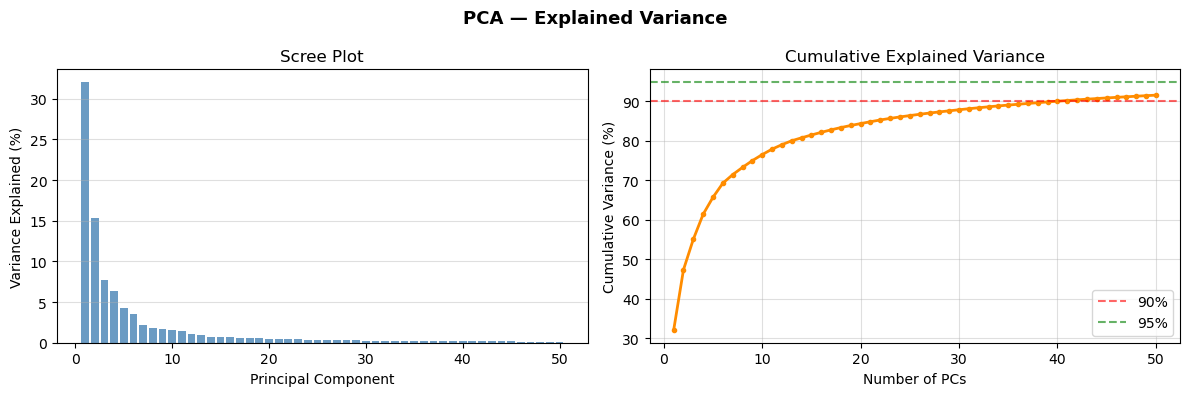

Saved: outputs\phase1_pca_variance.png


In [58]:
# Scree plot + cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
indvar = pca.explained_variance_ratio_ * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA — Explained Variance', fontsize=13, fontweight='bold')

ax1.bar(range(1, 51), indvar, color='steelblue', alpha=0.8)
ax1.set_title('Scree Plot')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.grid(axis='y', alpha=0.4)

ax2.plot(range(1, 51), cumvar, 'o-', color='darkorange', linewidth=2, markersize=3)
ax2.axhline(90, color='red',   linestyle='--', alpha=0.6, label='90%')
ax2.axhline(95, color='green', linestyle='--', alpha=0.6, label='95%')
idx95 = np.argmax(cumvar >= 95)
if cumvar[idx95] >= 95:
    ax2.axvline(idx95+1, color='green', linestyle=':', alpha=0.7)
    ax2.annotate(f'PC {idx95+1}\n95% var', xy=(idx95+1, cumvar[idx95]),
                 xytext=(idx95+4, cumvar[idx95]-10),
                 fontsize=9, arrowprops=dict(arrowstyle='->', color='green'))
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend(); ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_pca_variance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_pca_variance.png")}')

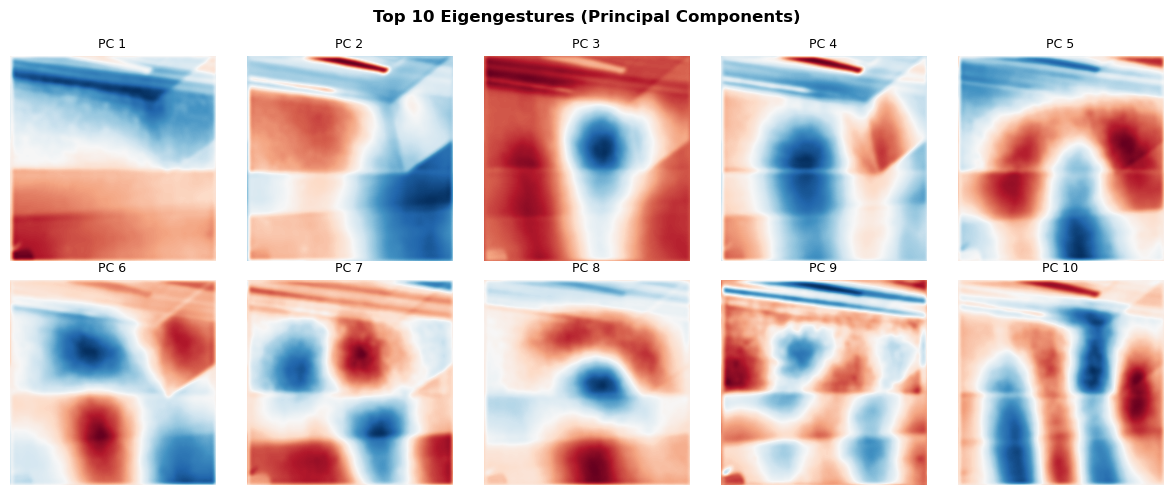

Saved: outputs\phase1_eigengestures.png


In [59]:
# Top 10 Eigengestures
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Top 10 Eigengestures (Principal Components)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    eg = pca.components_[i].reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(eg, cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_eigengestures.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "phase1_eigengestures.png")}')

---
## 5B. 📚 PCA — Step-by-Step Educational Walkthrough

> **Why this section exists:** The `ManualPCA` class above encapsulates all the math.  
> Here we **unpack every step individually** so you can see and explain each one clearly — perfect for a viva or exam.

### What is PCA? (Simple Explanation)

**Principal Component Analysis (PCA)** is a mathematical technique that:
1. Finds the directions of **maximum variance** in the data
2. Projects the data onto those directions (called **principal components**)
3. Keeps only the top-*k* directions → **dimensionality reduction**

Think of it like this: if you have a cloud of points in 40,000-dimensional space (one dimension per pixel), PCA finds the 50 "views" that capture the most information, and throws away the rest.

**Mathematical idea:**
- We want directions **v** such that the projected data **Xv** has maximum variance
- This is exactly the **eigenvector problem** on the covariance matrix: **Σv = λv**
- Eigenvectors with the **largest eigenvalues** capture the most variance

In [60]:
# ─── Step 1: Flatten images into feature vectors ───────────────────────────
# Each 200×200 image becomes a 1D vector of 40,000 pixel values.
# This gives us a data matrix X of shape (N_samples, N_features).

N      = final_images.shape[0]          # number of images
X_flat = final_images.reshape(N, -1)    # shape: (N, 200*200) = (N, 40000)

print(f"Step 1 — Flatten Images")
print(f"  Image shape      : {final_images.shape[1]}×{final_images.shape[2]} = {final_images.shape[1]*final_images.shape[2]} features")
print(f"  Data matrix X    : {X_flat.shape}  (rows=samples, cols=pixels)")

Step 1 — Flatten Images
  Image shape      : 200×200 = 40000 features
  Data matrix X    : (2900, 40000)  (rows=samples, cols=pixels)


### Step 2: Compute the Mean Image

The **mean image** (μ) is the pixel-wise average across all training images.  
Subtracting it **centers** the data around zero — this is required before PCA.

**Formula:** μ = (1/N) · Σᵢ xᵢ

Step 2 — Mean Image
  mean_image shape : (40000,)
  Pixel value range: [0.1, 0.8]


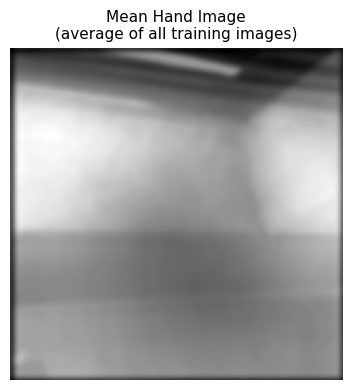

Saved: outputs\pca_mean_image.png


In [61]:
# ─── Step 2: Mean image ─────────────────────────────────────────────────────
mean_image = np.mean(X_flat, axis=0)   # shape: (40000,)

print(f"Step 2 — Mean Image")
print(f"  mean_image shape : {mean_image.shape}")
print(f"  Pixel value range: [{mean_image.min():.1f}, {mean_image.max():.1f}]")

# Visualise the mean image
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(mean_image.reshape(200, 200), cmap='gray')
ax.set_title('Mean Hand Image\n(average of all training images)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_mean_image.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "pca_mean_image.png")}')

### Step 3: Center the Data (Mean Subtraction)

We subtract the mean from every sample:  **X_centered = X − μ**

After this, the dataset has zero mean.  
Centering ensures PCA finds directions of variance, not just directions away from the origin.

In [62]:
# ─── Step 3: Mean centering ─────────────────────────────────────────────────
X_centered = X_flat - mean_image      # broadcast: each row minus the mean vector

print(f"Step 3 — Mean Centering")
print(f"  X_centered shape : {X_centered.shape}")
print(f"  Mean after center: {X_centered.mean():.6f}  (should be ~0)")

Step 3 — Mean Centering
  X_centered shape : (2900, 40000)
  Mean after center: 0.000000  (should be ~0)


### Step 4: Covariance Matrix

The covariance matrix **Σ** tells us how much each pair of pixel dimensions varies together.

**Formula:** Σ = (1/(N−1)) · Xᶜᵀ · Xᶜ

The true Σ has shape **(40000 × 40000)** — impossible to compute directly!  
We use the **surrogate (kernel) trick**: compute the small **(N × N)** matrix **L = Xᶜ · Xᶜᵀ** instead.  
Its eigenvectors can be projected back to get the full eigenvectors of Σ.

In [63]:
# ─── Step 4: Surrogate covariance matrix (N×N instead of D×D) ──────────────
# The true covariance Σ = Xc.T @ Xc / (N-1) has shape (D, D) = (40000, 40000)
# That would require ~12 GB RAM and is computationally infeasible.
#
# Trick: compute the SURROGATE matrix L = Xc @ Xc.T / (N-1) of shape (N, N).
# L and Σ share the same non-zero eigenvalues, and we can recover Σ's eigenvectors
# by projecting L's eigenvectors: u_i = Xc.T @ v_i  (then normalize).

L = X_centered @ X_centered.T / (N - 1)    # shape: (N, N)

print(f"Step 4 — Covariance Matrix (surrogate)")
print(f"  True covariance shape    : ({X_flat.shape[1]}, {X_flat.shape[1]}) — {X_flat.shape[1]**2 * 8 / 1e9:.1f} GB RAM needed!")
print(f"  Surrogate matrix L shape : {L.shape}  ← {L.nbytes / 1e6:.1f} MB — manageable")
print(f"  L is symmetric           : {np.allclose(L, L.T)}")
print()
print(f"  Formula: L = Xc @ Xc.T / (N-1)")
print(f"           shape = ({N}, {X_flat.shape[1]}) @ ({X_flat.shape[1]}, {N}) / {N-1} = {L.shape}")

Step 4 — Covariance Matrix (surrogate)
  True covariance shape    : (40000, 40000) — 12.8 GB RAM needed!
  Surrogate matrix L shape : (2900, 2900)  ← 67.3 MB — manageable
  L is symmetric           : True

  Formula: L = Xc @ Xc.T / (N-1)
           shape = (2900, 40000) @ (40000, 2900) / 2899 = (2900, 2900)


### Step 5: Eigenvalue Decomposition

We compute the eigenvalues **λ** and eigenvectors **v** of the surrogate matrix **L**.

**Equation:** L · v = λ · v

- **Eigenvalues (λ)** → amount of variance captured by each direction
- **Eigenvectors (v)** → the directions themselves (principal components in the surrogate space)

We use `np.linalg.eigh` which is optimized for symmetric matrices and returns real eigenvalues.

In [64]:
# ─── Step 5: Eigenvalue decomposition ───────────────────────────────────────
# np.linalg.eigh — optimized for symmetric/Hermitian matrices.
# Returns REAL eigenvalues in ASCENDING order.
eigenvalues_raw, eigenvectors_raw = np.linalg.eigh(L)

print(f"Step 5 — Eigenvalue Decomposition")
print(f"  Eigenvalues  shape   : {eigenvalues_raw.shape}")
print(f"  Eigenvectors shape   : {eigenvectors_raw.shape}")
print(f"  Eigenvalue range     : [{eigenvalues_raw.min():.4f}, {eigenvalues_raw.max():.4f}]")
print(f"  Top 10 (descending)  : {eigenvalues_raw[-10:][::-1].round(4)}")
print()
print("  Interpretation: each eigenvalue = variance captured by that eigenvector direction.")
print("  Larger eigenvalue → that direction explains more of the data's spread.")

Step 5 — Eigenvalue Decomposition
  Eigenvalues  shape   : (2900,)
  Eigenvectors shape   : (2900, 2900)
  Eigenvalue range     : [-0.0000, 911.6640]
  Top 10 (descending)  : [911.664  436.9947 219.9    180.532  122.4369 101.5133  61.6729  52.3123
  48.8852  43.2818]

  Interpretation: each eigenvalue = variance captured by that eigenvector direction.
  Larger eigenvalue → that direction explains more of the data's spread.


### Step 6: Sort Eigenvalues in Descending Order

Eigenvalues represent **variance captured**.  
We sort them from **largest to smallest** so that PC-1 captures the most variance, PC-2 the second most, etc.

In [65]:
# ─── Step 6: Sort descending by eigenvalue ──────────────────────────────────
sort_idx     = np.argsort(eigenvalues_raw)[::-1]     # indices of sorted eigenvalues
eigenvalues  = eigenvalues_raw[sort_idx]
eigenvectors = eigenvectors_raw[:, sort_idx]          # reorder columns

print(f"Step 6 — Sorted Eigenvalues (top 10):")
for i, ev in enumerate(eigenvalues[:10]):
    print(f"  PC {i+1:2d} : λ = {ev:.2f}")

Step 6 — Sorted Eigenvalues (top 10):
  PC  1 : λ = 911.66
  PC  2 : λ = 436.99
  PC  3 : λ = 219.90
  PC  4 : λ = 180.53
  PC  5 : λ = 122.44
  PC  6 : λ = 101.51
  PC  7 : λ = 61.67
  PC  8 : λ = 52.31
  PC  9 : λ = 48.89
  PC 10 : λ = 43.28


### Step 7: Project Eigenvectors Back to Pixel Space

The surrogate eigenvectors are in **sample space** (length N).  
We recover the true eigenvectors in **pixel space** (length 40000) using:

**u_i = Xᶜᵀ · v_i** (then normalize to unit length)

These pixel-space eigenvectors are the **"eigengestures"** — the basis images that make up all hand gestures.

In [66]:
# ─── Step 7: Recover pixel-space eigenvectors ───────────────────────────────
components_raw = X_centered.T @ eigenvectors            # shape: (40000, N)
norms          = np.linalg.norm(components_raw, axis=0) # norm of each column
components     = components_raw / (norms + 1e-10)       # normalize

print(f"Step 7 — Pixel-Space Eigenvectors")
print(f"  components shape : {components.shape}  (pixels × principal components)")

# Select top-k components
K_COMPONENTS = 50
top_components = components[:, :K_COMPONENTS]           # shape: (40000, 50)
print(f"  Selected top {K_COMPONENTS} components : {top_components.shape}")

Step 7 — Pixel-Space Eigenvectors
  components shape : (40000, 2900)  (pixels × principal components)
  Selected top 50 components : (40000, 50)


### Step 8: Explained Variance Ratio

The **explained variance ratio** tells us what fraction of total information each PC captures.

**Formula:** EVR_i = λ_i / Σλ

This is crucial for choosing how many components to keep.

Step 8 — Explained Variance
  Top 50 PCs capture : 91.6% of total variance

  PC-by-PC breakdown (first 10):
    PC  1: 32.02%  (cumulative: 32.0%)
    PC  2: 15.35%  (cumulative: 47.4%)
    PC  3: 7.72%  (cumulative: 55.1%)
    PC  4: 6.34%  (cumulative: 61.4%)
    PC  5: 4.30%  (cumulative: 65.7%)
    PC  6: 3.57%  (cumulative: 69.3%)
    PC  7: 2.17%  (cumulative: 71.5%)
    PC  8: 1.84%  (cumulative: 73.3%)
    PC  9: 1.72%  (cumulative: 75.0%)
    PC 10: 1.52%  (cumulative: 76.5%)


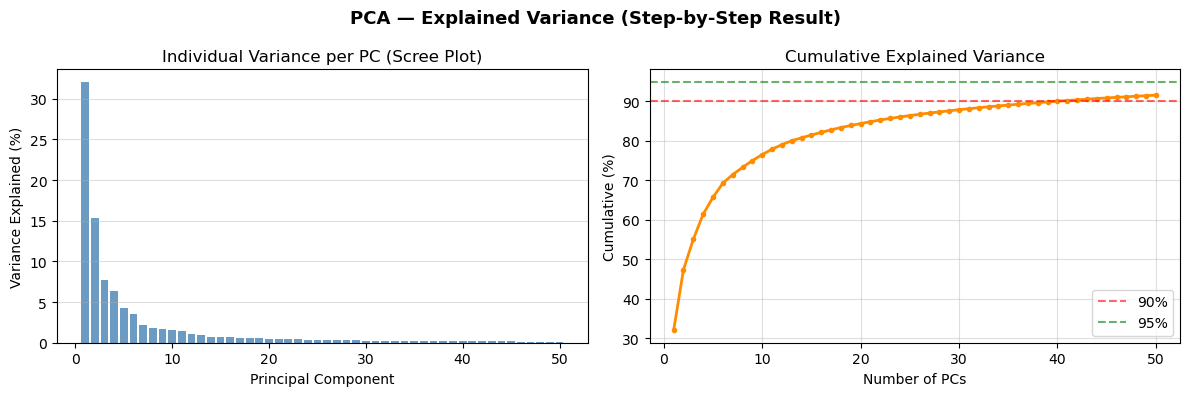

Saved: outputs\pca_explained_variance_stepwise.png


In [67]:
# ─── Step 8: Explained variance ratio ───────────────────────────────────────
eigenvalues_clipped = np.maximum(eigenvalues, 0)        # remove numerical negatives
total_variance      = eigenvalues_clipped.sum() + 1e-10
evr                 = eigenvalues_clipped[:K_COMPONENTS] / total_variance

cumvar = np.cumsum(evr) * 100
indvar = evr * 100

print(f"Step 8 — Explained Variance")
print(f"  Top {K_COMPONENTS} PCs capture : {cumvar[-1]:.1f}% of total variance")
print()
print(f"  PC-by-PC breakdown (first 10):")
for i in range(10):
    print(f"    PC {i+1:2d}: {indvar[i]:.2f}%  (cumulative: {cumvar[i]:.1f}%)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA — Explained Variance (Step-by-Step Result)', fontsize=13, fontweight='bold')

ax1.bar(range(1, K_COMPONENTS+1), indvar, color='steelblue', alpha=0.8)
ax1.set_title('Individual Variance per PC (Scree Plot)')
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Variance Explained (%)')
ax1.grid(axis='y', alpha=0.4)

ax2.plot(range(1, K_COMPONENTS+1), cumvar, 'o-', color='darkorange', lw=2, ms=3)
ax2.axhline(90, color='red',   ls='--', alpha=0.6, label='90%')
ax2.axhline(95, color='green', ls='--', alpha=0.6, label='95%')
idx95 = np.argmax(cumvar >= 95)
if cumvar[idx95] >= 95:
    ax2.axvline(idx95+1, color='green', ls=':', alpha=0.7)
    ax2.annotate(f'PC {idx95+1}\n95%', xy=(idx95+1, cumvar[idx95]),
                 xytext=(idx95+5, cumvar[idx95]-12), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'))
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of PCs'); ax2.set_ylabel('Cumulative (%)')
ax2.legend(); ax2.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_explained_variance_stepwise.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "pca_explained_variance_stepwise.png")}')

### Step 9: Project Data (Dimensionality Reduction)

We project each image onto the top-K eigenvectors:

**z_i = (x_i − μ) · Uᵏᵀ**

- Input:  **x_i** ∈ ℝ⁴⁰⁰⁰⁰  (40,000 pixel values)
- Output: **z_i** ∈ ℝᴷ       (K = 50 PCA coefficients)

This is the **feature vector** we feed into the classifier.

In [68]:
# ─── Step 9: Project data to PCA space ──────────────────────────────────────
U_k = top_components.T                          # shape: (K, 40000)  — projection matrix
X_pca_step = (X_flat - mean_image) @ U_k.T     # shape: (N, K)

print(f"Step 9 — Projection (Dimensionality Reduction)")
print(f"  Original   : {X_flat.shape}  ({X_flat.shape[1]} features per image)")
print(f"  PCA output : {X_pca_step.shape}  ({K_COMPONENTS} features per image)")
print(f"  Compression ratio : {X_flat.shape[1] / K_COMPONENTS:.0f}×  smaller!")

Step 9 — Projection (Dimensionality Reduction)
  Original   : (2900, 40000)  (40000 features per image)
  PCA output : (2900, 50)  (50 features per image)
  Compression ratio : 800×  smaller!


### Step 10: Reconstruct Images from PCA Space

We can **reconstruct** an image from its PCA representation:

**x̂_i = z_i · Uᵏ + μ**

The reconstructed image is an approximation.  
With more components, the reconstruction improves.  
This visually proves that PCA has captured the important information.

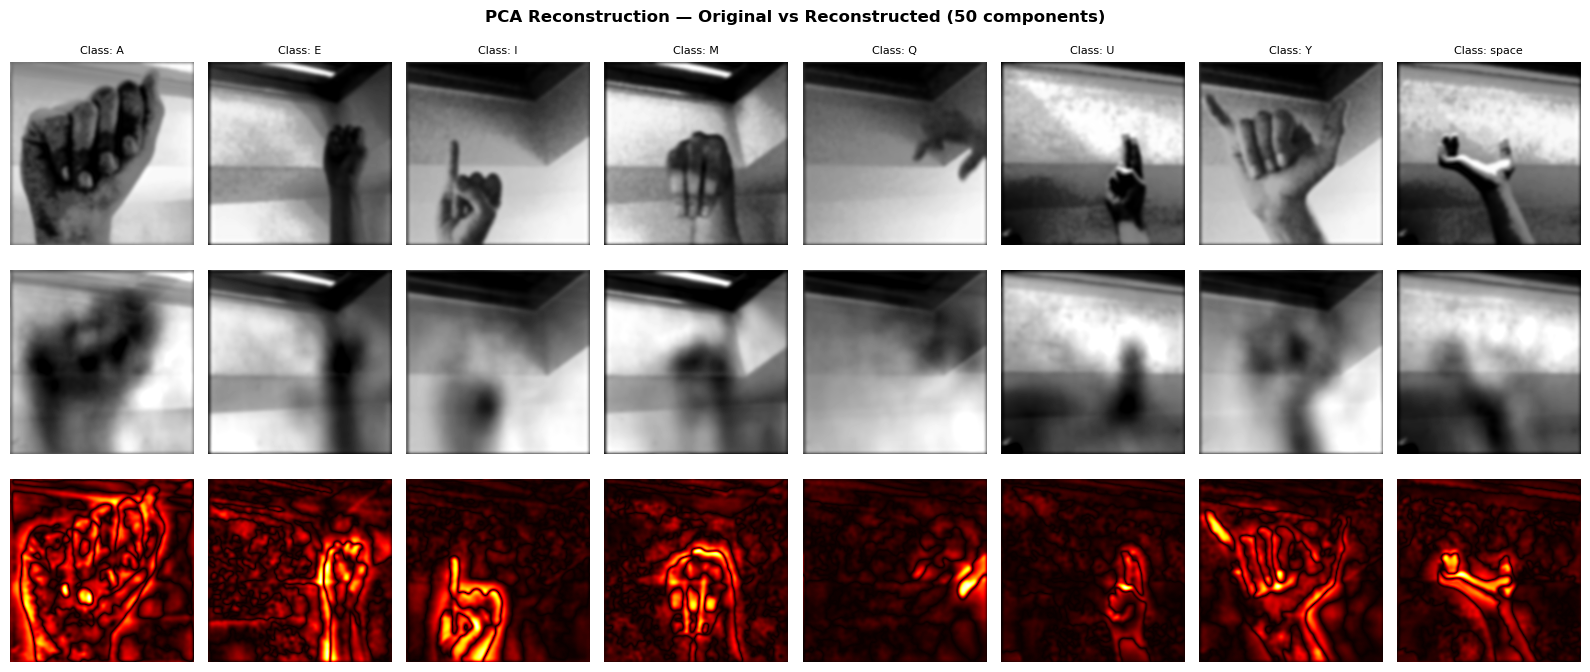

Saved: outputs\pca_reconstruction.png


In [69]:
# ─── Step 10: Reconstruction ────────────────────────────────────────────────
def reconstruct(X_pca_repr, components_T, mean_img):
    """Reconstruct images from PCA representation back to pixel space."""
    return X_pca_repr @ components_T + mean_img

X_reconstructed = reconstruct(X_pca_step, U_k, mean_image)  # shape: (N, 40000)

# Show original vs reconstruction for a few samples
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle(f'PCA Reconstruction — Original vs Reconstructed ({K_COMPONENTS} components)',
             fontsize=12, fontweight='bold')

sample_indices = np.linspace(0, N-1, 8, dtype=int)
for col, idx in enumerate(sample_indices):
    orig  = X_flat[idx].reshape(200, 200)
    recon = X_reconstructed[idx].reshape(200, 200)
    diff  = np.abs(orig - recon)

    # Images are in [0,1] range — let matplotlib auto-scale (no vmin/vmax)
    axes[0, col].imshow(orig,  cmap='gray')
    axes[0, col].set_title(f'Class: {CLASSES[labels[idx]]}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(np.clip(recon, 0, 1), cmap='gray')
    axes[1, col].axis('off')

    axes[2, col].imshow(diff,  cmap='hot')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=9, rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9, rotation=90, labelpad=5)
axes[2, 0].set_ylabel('|Difference|',  fontsize=9, rotation=90, labelpad=5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_reconstruction.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "pca_reconstruction.png")}')

### Step 10B: Effect of Number of Components on Reconstruction

Let's see how reconstruction quality improves as we use more principal components.  
This is one of the most compelling visual proofs of what PCA is doing.

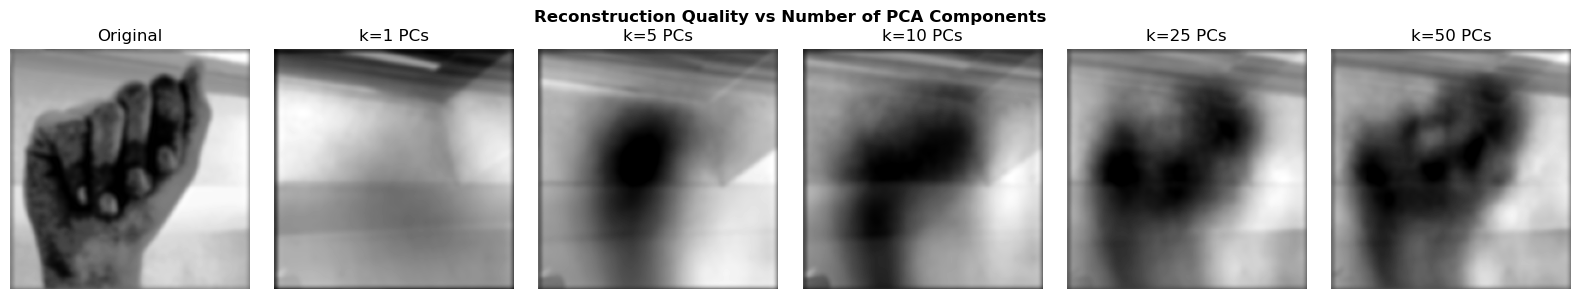

Saved: outputs\pca_reconstruction_k_comparison.png


In [70]:
# Reconstruction quality vs number of components
k_values = [1, 5, 10, 25, 50]
test_img  = X_flat[0]   # use first image as demo

fig, axes = plt.subplots(1, len(k_values)+1, figsize=(16, 3))
fig.suptitle('Reconstruction Quality vs Number of PCA Components', fontsize=12, fontweight='bold')

axes[0].imshow(test_img.reshape(200,200), cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')

for ax, k in zip(axes[1:], k_values):
    Uk    = top_components[:, :k].T          # (k, 40000)
    z     = (test_img - mean_image) @ Uk.T  # project
    recon = z @ Uk + mean_image              # reconstruct
    ax.imshow(np.clip(recon.reshape(200,200), 0, 255), cmap='gray')
    ax.set_title(f'k={k} PCs')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_reconstruction_k_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "pca_reconstruction_k_comparison.png")}')

---
## 6. 🔀 Data Splitting (Train / Test)

We split the PCA-projected features into training and test sets.  
We use **80% for training** and **20% for testing**.  
`stratify=labels` ensures each class is proportionally represented in both sets.

In [71]:
# Use the PCA output from the step-by-step section
X_features = X_pca_step   # shape: (N, K_COMPONENTS)
y_labels   = labels

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_labels
)

print("Train / Test Split")
print(f"  Total samples  : {len(X_features)}")
print(f"  Training set   : {X_train.shape}  ({len(X_train)} images, {X_train.shape[1]} PCA features each)")
print(f"  Test set       : {X_test.shape}  ({len(X_test)} images)")
print(f"  Classes        : {len(np.unique(y_labels))}")

Train / Test Split
  Total samples  : 2900
  Training set   : (2320, 50)  (2320 images, 50 PCA features each)
  Test set       : (580, 50)  (580 images)
  Classes        : 29


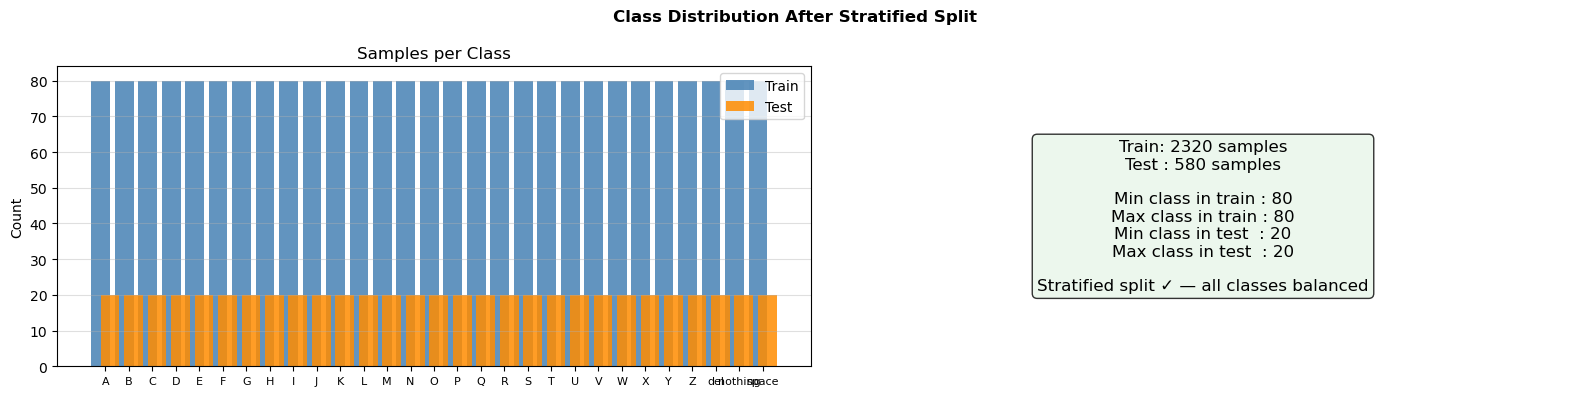

Saved: outputs\class_distribution.png
Stratification confirmed: every class has 20–20 test samples.


In [72]:
# Verify class balance is preserved after stratified split
train_counts = np.bincount(y_train, minlength=len(CLASSES))
test_counts  = np.bincount(y_test,  minlength=len(CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Class Distribution After Stratified Split', fontsize=12, fontweight='bold')

x = np.arange(len(CLASSES))
w = 0.4
axes[0].bar(x, train_counts, color='steelblue', alpha=0.85, label='Train')
axes[0].bar(x + w, test_counts, color='darkorange', alpha=0.85, label='Test')
axes[0].set_xticks(x + w/2); axes[0].set_xticklabels(CLASSES, fontsize=8)
axes[0].set_title('Samples per Class'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)

axes[1].text(0.5, 0.5,
    f'Train: {len(X_train)} samples\n'
    f'Test : {len(X_test)} samples\n\n'
    f'Min class in train : {train_counts.min()}\n'
    f'Max class in train : {train_counts.max()}\n'
    f'Min class in test  : {test_counts.min()}\n'
    f'Max class in test  : {test_counts.max()}\n\n'
    f'Stratified split ✓ — all classes balanced',
    transform=axes[1].transAxes,
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8))
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "class_distribution.png")}')
print(f'Stratification confirmed: every class has {test_counts.min()}–{test_counts.max()} test samples.')

---
## 7. 🤖 Classification — K-Nearest Neighbors (KNN) — Manual Implementation

**Why KNN?**
- Simple and easy to understand — no training phase, just memorize the data
- Works well in low-dimensional PCA space
- Intuitive: classify a new image by finding the K most similar training images

**How it works:**
1. For each test image, compute the **Euclidean distance** to every training image (in PCA space)
2. Find the **K nearest neighbors**
3. Assign the **majority class label** among those K neighbors

**Implementation:** Fully from scratch using NumPy only — no `sklearn.KNeighborsClassifier`.


In [73]:
class ManualKNN:
    """
    K-Nearest Neighbors classifier — implemented from scratch (NumPy only).
    No sklearn.neighbors or any built-in classifier is used.

    Algorithm:
      fit   : memorize training features and labels
      predict: for each test sample, compute Euclidean distance to all training
               samples, find the K closest, return the majority vote label.
    """
    def __init__(self, n_neighbors=5):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # KNN has no training step — just store the data
        self.X_train = X.copy()
        self.y_train = y.copy()
        return self

    def _euclidean_distances(self, x_test_single):
        """Compute Euclidean distance from one test sample to all training samples."""
        # ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a.b  — vectorized, no loops over training set
        diff = self.X_train - x_test_single   # (N_train, D) broadcast
        return np.sqrt((diff ** 2).sum(axis=1))

    def predict_single(self, x):
        """Predict label for a single test sample."""
        dists   = self._euclidean_distances(x)           # (N_train,)
        knn_idx = np.argsort(dists)[:self.k]             # indices of K smallest distances
        knn_labels = self.y_train[knn_idx]               # labels of K neighbors
        # Majority vote — pick the label with the highest count
        counts = np.bincount(knn_labels, minlength=len(np.unique(self.y_train)))
        return int(np.argmax(counts))

    def predict(self, X_test):
        """Predict labels for all test samples."""
        return np.array([self.predict_single(x) for x in X_test])


# ── Train (fit) ──────────────────────────────────────────────────────────────
K_NEIGHBORS = 5
knn = ManualKNN(n_neighbors=K_NEIGHBORS)

t0 = time.time()
knn.fit(X_train, y_train)
print(f"Manual KNN Training (K={K_NEIGHBORS})")
print(f"  Fit done in {time.time()-t0:.3f}s  (KNN just stores the training data)")
print(f"  Training samples : {len(X_train)}")
print(f"  Feature dims     : {X_train.shape[1]} (PCA components)")


Manual KNN Training (K=5)
  Fit done in 0.009s  (KNN just stores the training data)
  Training samples : 2320
  Feature dims     : 50 (PCA components)


In [74]:
# ── Predict ──────────────────────────────────────────────────────────────────
print(f"Running Manual KNN prediction on {len(X_test)} test samples...")
print("(This may take ~1-2 minutes — pure NumPy, no optimised C backend)")
t0 = time.time()
y_pred = knn.predict(X_test)
elapsed = time.time() - t0
print(f"Prediction complete in {elapsed:.1f}s")
print(f"  Sample predictions (first 10): {[CLASSES[p] for p in y_pred[:10]]}")
print(f"  True labels       (first 10): {[CLASSES[t] for t in y_test[:10]]}")


Running Manual KNN prediction on 580 test samples...
(This may take ~1-2 minutes — pure NumPy, no optimised C backend)
Prediction complete in 0.3s
  Sample predictions (first 10): ['O', 'Y', 'Z', 'I', 'O', 'D', 'B', 'A', 'A', 'space']
  True labels       (first 10): ['O', 'Y', 'Z', 'I', 'M', 'C', 'I', 'I', 'A', 'space']


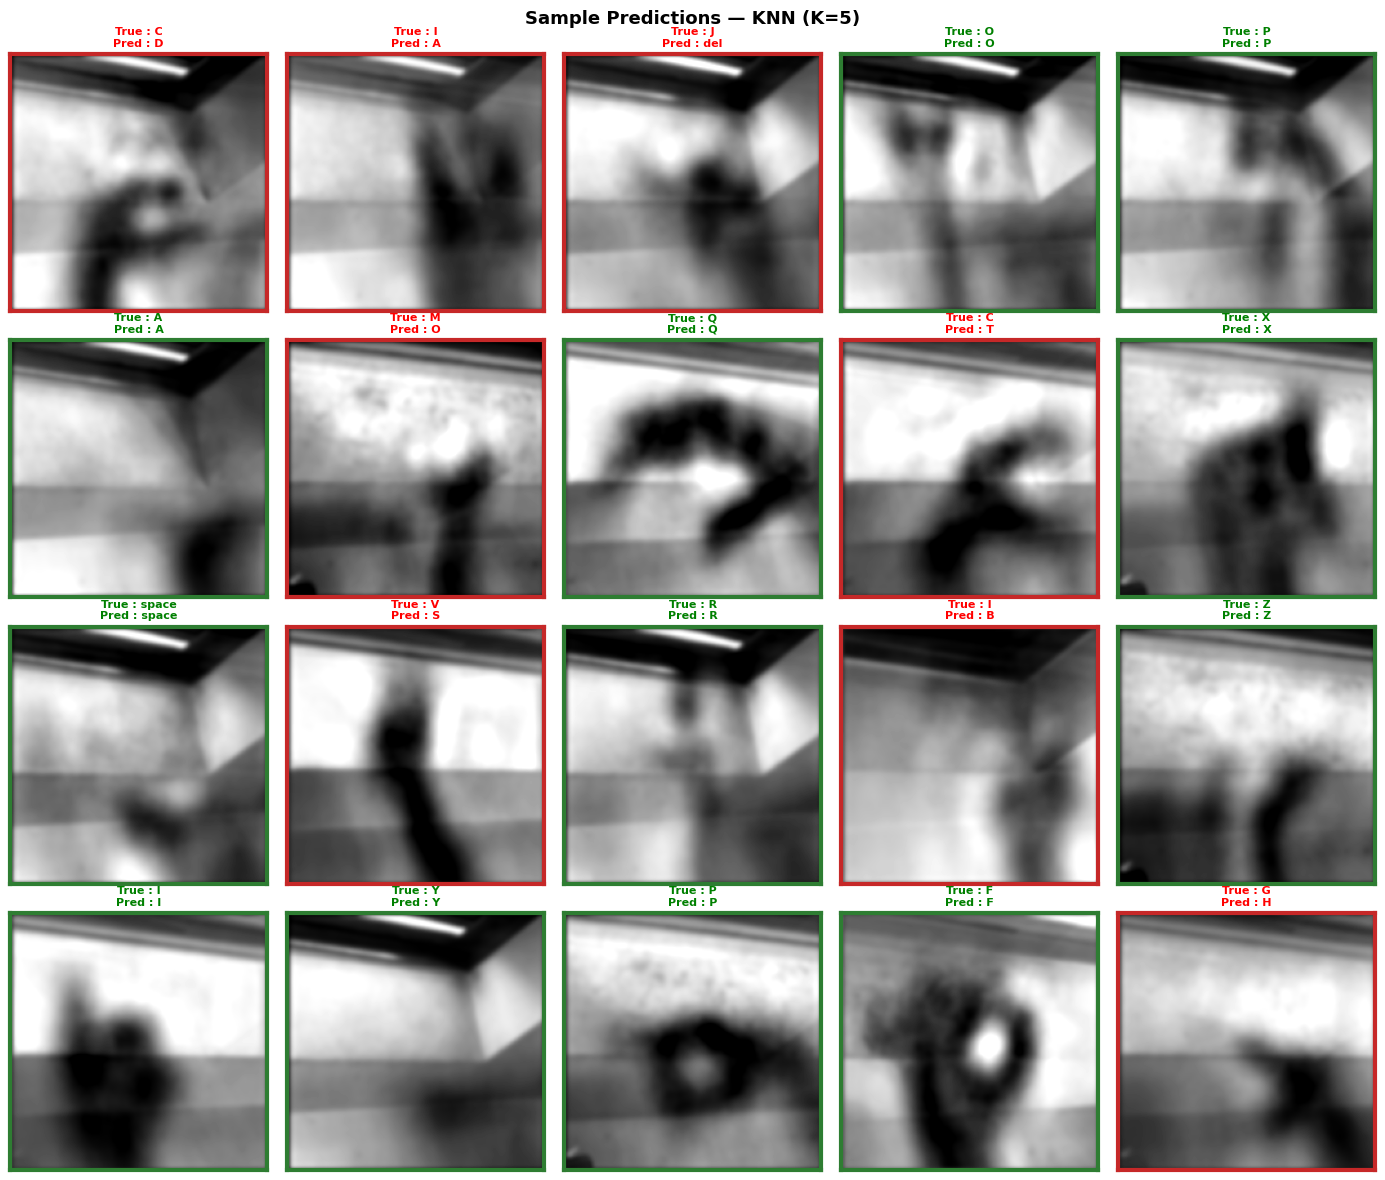

Saved: outputs\sample_predictions.png
Green title = correct prediction | Red title = wrong prediction


In [75]:
# Visualize sample predictions — show test images with True vs Predicted labels
n_show = 20
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle(f'Sample Predictions — KNN (K={K_NEIGHBORS})', fontsize=13, fontweight='bold')
axes = axes.flatten()

# Pick a mix of correct and incorrect predictions to show
wrong_idx   = np.where(y_pred != y_test)[0]
correct_idx = np.where(y_pred == y_test)[0]
show_idx    = np.concatenate([wrong_idx[:8], correct_idx[:12]])[:n_show]
np.random.shuffle(show_idx)

for i, idx in enumerate(show_idx[:n_show]):
    # Reconstruct image from PCA features back to pixel space
    z     = X_test[idx]                              # PCA feature vector
    recon = z @ U_k + mean_image                    # reconstruct to pixel space
    img   = np.clip(recon.reshape(IMG_SIZE, IMG_SIZE), 0, 1)

    correct = (y_pred[idx] == y_test[idx])
    border_color = '#2e7d32' if correct else '#c62828'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f'True : {CLASSES[y_test[idx]]}\nPred : {CLASSES[y_pred[idx]]}',
        fontsize=8,
        color='green' if correct else 'red',
        fontweight='bold'
    )
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "sample_predictions.png")}')
print('Green title = correct prediction | Red title = wrong prediction')

---
## 8. 📊 Evaluation — Metrics & Results

We evaluate using three standard metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | % of correctly classified images |
| **Precision** | Of all predicted as class X, how many truly are X |
| **Recall** | Of all true class X, how many did we correctly find |
| **F1-Score** | Harmonic mean of precision and recall |
| **Confusion Matrix** | Which classes get confused with which |

In [76]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"{'='*50}")
print(f"  CLASSIFICATION ACCURACY: {acc*100:.2f}%")
print(f"{'='*50}")
print()

# Full classification report
print("Classification Report (per class):")
print(classification_report(y_test, y_pred, target_names=CLASSES))

  CLASSIFICATION ACCURACY: 45.17%

Classification Report (per class):
              precision    recall  f1-score   support

           A       0.29      0.40      0.33        20
           B       0.38      0.60      0.46        20
           C       0.73      0.55      0.63        20
           D       0.43      0.50      0.47        20
           E       0.25      0.30      0.27        20
           F       0.76      0.65      0.70        20
           G       0.50      0.65      0.57        20
           H       0.30      0.35      0.33        20
           I       0.45      0.50      0.48        20
           J       0.71      0.60      0.65        20
           K       0.41      0.60      0.49        20
           L       0.58      0.70      0.64        20
           M       0.37      0.55      0.44        20
           N       0.58      0.55      0.56        20
           O       0.50      0.15      0.23        20
           P       0.68      0.65      0.67        20
           

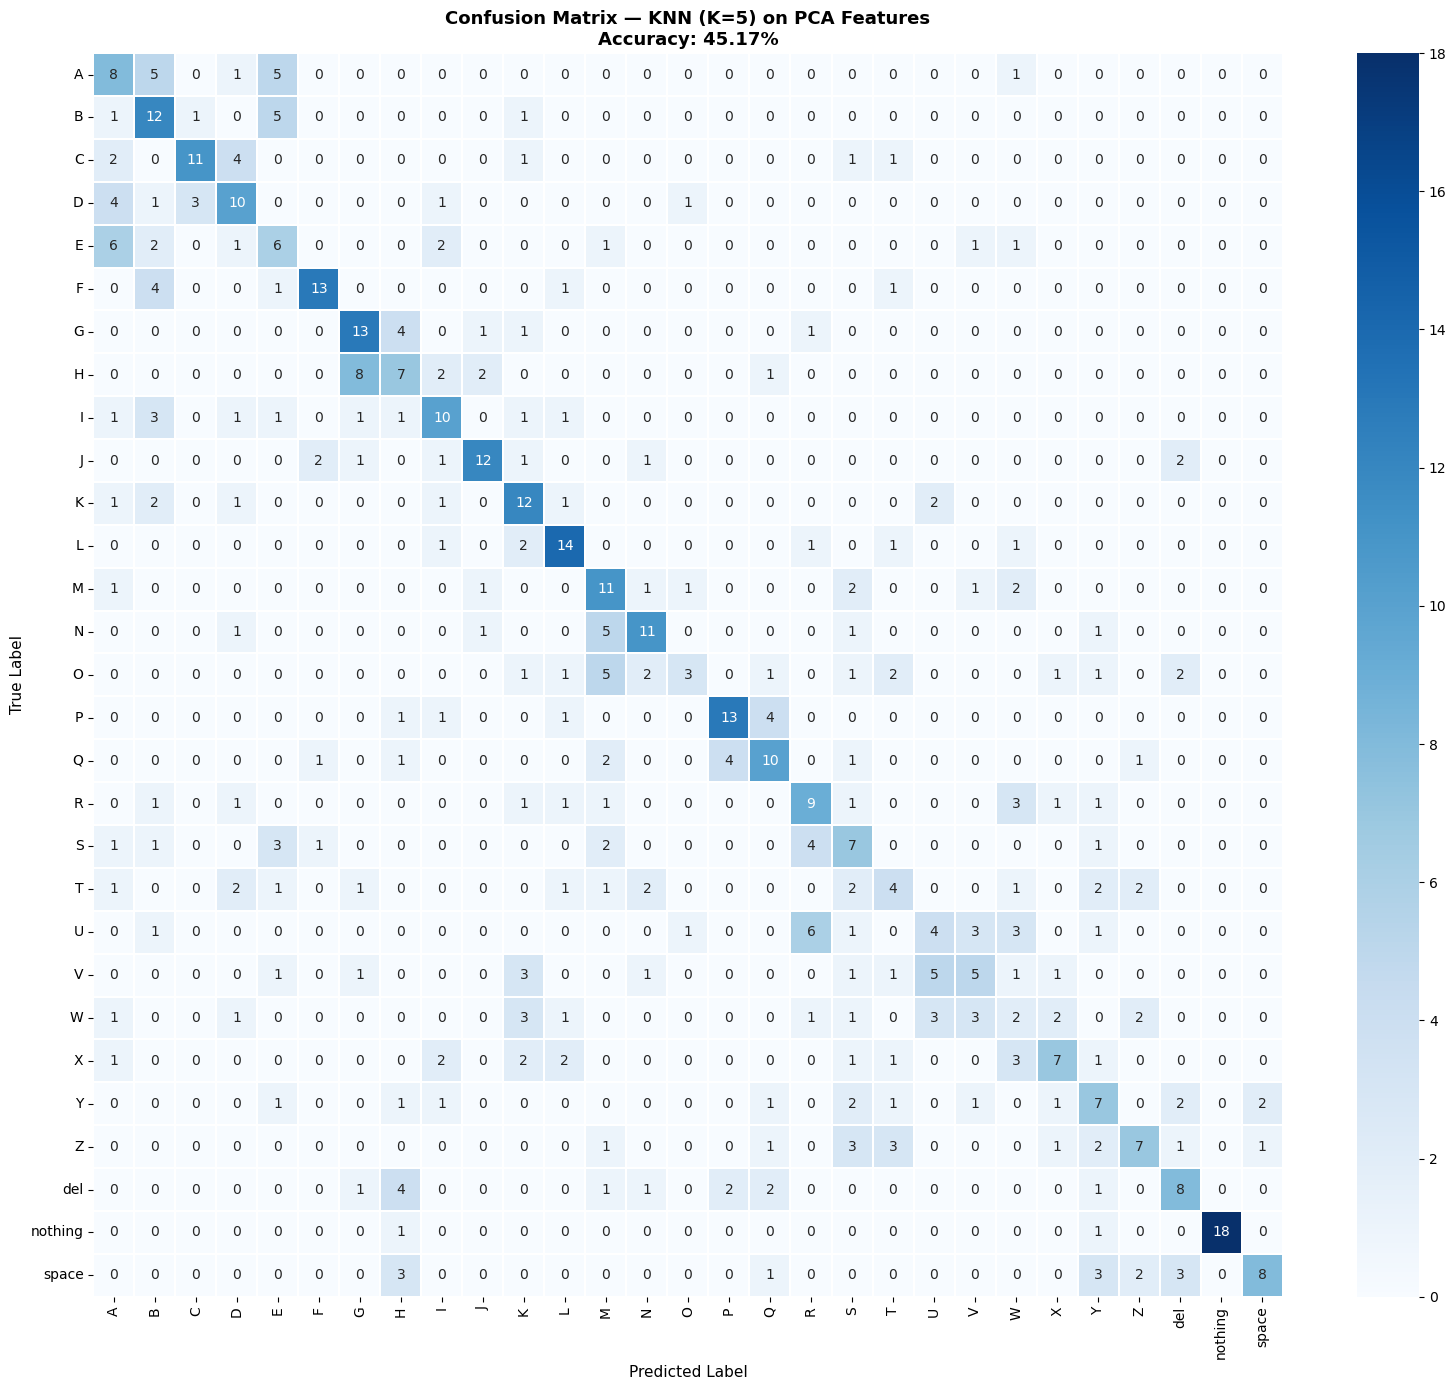

Saved: outputs\confusion_matrix.png


In [77]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=CLASSES, yticklabels=CLASSES,
    cmap='Blues', linewidths=0.3,
    ax=ax
)
ax.set_title(f'Confusion Matrix — KNN (K={K_NEIGHBORS}) on PCA Features\nAccuracy: {acc*100:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "confusion_matrix.png")}')

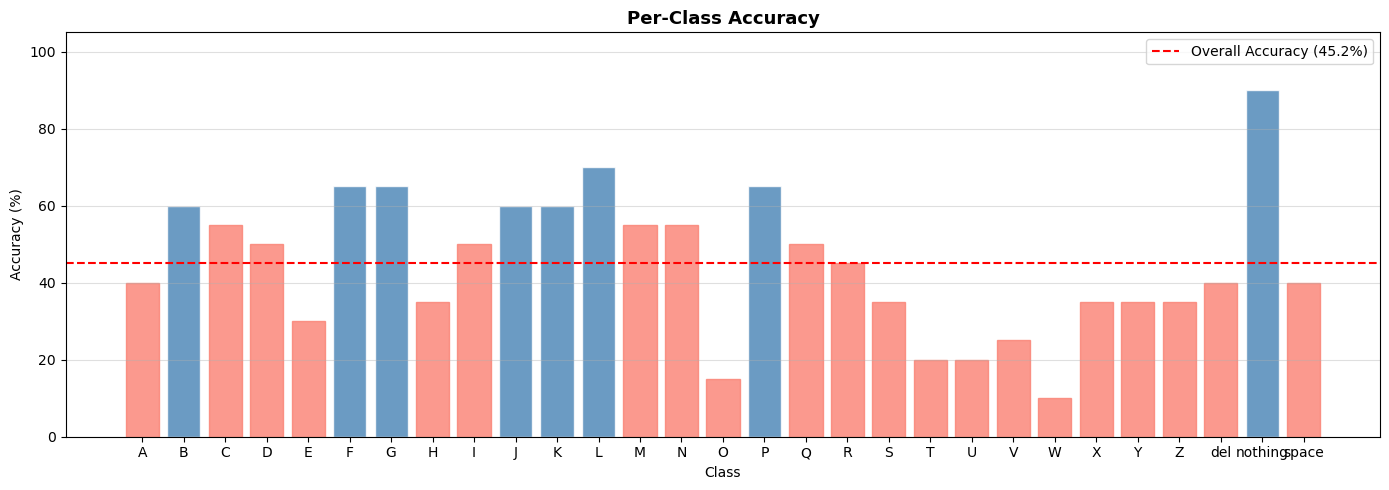

Saved: outputs\per_class_accuracy.png


In [78]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASSES, per_class_acc * 100, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(acc*100, color='red', ls='--', lw=1.5, label=f'Overall Accuracy ({acc*100:.1f}%)')
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Color bars below 60% red
for bar, val in zip(bars, per_class_acc):
    if val < 0.6:
        bar.set_color('salmon')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(OUTPUT_DIR, "per_class_accuracy.png")}')

---
## 9. 🔬 Hyperparameter Analysis — Effect of K on Accuracy

We test multiple values of K to find the best K for our Manual KNN classifier.  
This is good scientific practice — don't just guess K, measure it!

**Note:** Each K value re-runs the full manual KNN prediction, so this cell takes several minutes.


  K= 1  →  Accuracy: 65.69%
  K= 3  →  Accuracy: 51.72%
  K= 5  →  Accuracy: 45.17%
  K= 7  →  Accuracy: 42.24%
  K=10  →  Accuracy: 40.52%
  K=15  →  Accuracy: 36.72%
  K=20  →  Accuracy: 35.17%


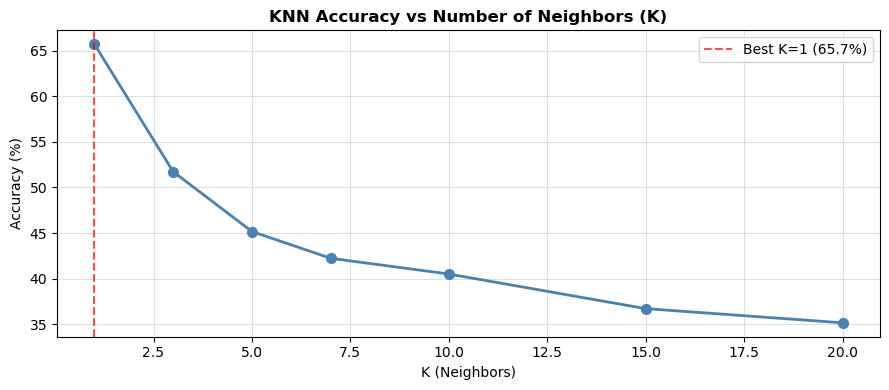


Best K = 1  →  Accuracy = 65.69%
Saved: outputs\knn_k_sweep.png


In [79]:
k_range   = [1, 3, 5, 7, 10, 15, 20]
k_results = []

for k in k_range:
    clf = ManualKNN(n_neighbors=k)
    clf.fit(X_train, y_train)
    a = accuracy_score(y_test, clf.predict(X_test))
    k_results.append(a)
    print(f"  K={k:2d}  →  Accuracy: {a*100:.2f}%")

best_k   = k_range[np.argmax(k_results)]
best_acc = max(k_results) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, [r*100 for r in k_results], 'o-', color='steelblue', lw=2, ms=7)
ax.axvline(best_k, color='red', ls='--', alpha=0.7, label=f'Best K={best_k} ({best_acc:.1f}%)')
ax.set_title('KNN Accuracy vs Number of Neighbors (K)', fontsize=12, fontweight='bold')
ax.set_xlabel('K (Neighbors)'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'knn_k_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest K = {best_k}  →  Accuracy = {best_acc:.2f}%")
print(f'Saved: {os.path.join(OUTPUT_DIR, "knn_k_sweep.png")}')

---
## 10. 🏁 Final Results & Conclusion

In [80]:
print('=' * 68)
print('   FINAL PROJECT RESULTS — Hand Gesture Recognition Using PCA')
print('=' * 68)
print()
print('  DATASET')
print(f'    Source          : ASL Alphabet (Kaggle)')
print(f'    Classes         : {len(CLASSES)}  ({", ".join(CLASSES[:5])}, ...)')
print(f'    Samples used    : {N}  ({SAMPLES_PER_CLASS} per class)')
print(f'    Image size      : {IMG_SIZE}×{IMG_SIZE} px (grayscale, normalized to [0,1])')
print()
print('  PREPROCESSING PIPELINE')
print('    1. Grayscale conversion       [PIL — on load]')
print('    2. Histogram equalization     [manual LUT — no built-ins]')
print('    3. Gaussian noise removal     [manual separable convolution, 5×5, σ=1.2]')
print('    4. Median filter              [manual — demonstrated on crop + scipy for pipeline]')
print('    5. Contrast stretching        [percentile p2–p98]')
print('    6. Normalization              [÷255 → [0,1]]')
print()
print('  FREQUENCY DOMAIN FILTERING')
print('    Fourier Transform             [np.fft.fft2 + fftshift]')
print('    Butterworth lowpass           [D0=30, order=2]')
print('    Inverse FFT                   [np.fft.ifft2]')
print('    Visualized: magnitude, phase, mask, filtered output')
print()
print('  FEATURE EXTRACTION — MANUAL PCA (NumPy only)')
print('    Steps implemented:')
print('      1. Flatten → data matrix X')
print('      2. Mean image computation')
print('      3. Mean centering (X − μ)')
print(f'      4. Surrogate covariance L : {L.shape}')
print('      5. Eigendecomposition      : np.linalg.eigh')
print('      6. Sort eigenvalues        : descending')
print('      7. Pixel-space eigenvectors: Xc.T @ v (normalized)')
print(f'      8. Explained variance      : {cumvar[-1]:.1f}%  ({K_COMPONENTS} components)')
print('      9. Projection              : z = (x − μ) · Uᵏᵀ')
print('     10. Reconstruction          : x̂ = z · Uᵏ + μ')
print(f'    Dimension reduction   : {X_flat.shape[1]:,}  →  {K_COMPONENTS}  ({X_flat.shape[1]//K_COMPONENTS}× compression)')
print()
print('  DATA SPLITTING')
print(f'    Train / Test : 80% / 20%  (stratified)')
print(f'    Train size   : {len(X_train)}  |  Test size: {len(X_test)}')
print()
print('  CLASSIFICATION — MANUAL KNN (NumPy only, no sklearn classifier)')
print(f'    Neighbors (K)         : {K_NEIGHBORS}')
print(f'    Test accuracy         : {acc*100:.2f}%')
print(f'    Best K (sweep 1–20)   : {best_k}  →  {best_acc:.2f}%')
print()
print(f'  OUTPUTS SAVED  (folder: {OUTPUT_DIR}/)')
outputs = [
    'dataset_samples.png',
    'phase1_histogram_equalization.png',
    'median_filter_comparison.png',
    'phase1_gaussian_filter.png',
    'phase1_contrast_stretching.png',
    'phase1_frequency_domain.png',
    'phase1_cutoff_comparison.png',
    'pca_mean_image.png',
    'phase1_pca_variance.png',
    'pca_explained_variance_stepwise.png',
    'pca_reconstruction.png',
    'pca_reconstruction_k_comparison.png',
    'class_distribution.png',
    'sample_predictions.png',
    'confusion_matrix.png',
    'per_class_accuracy.png',
    'knn_k_sweep.png',
]
n_pages = int(np.ceil(len(CLASSES) / 10))
outputs += [f'phase1_full_spatial_pipeline_p{p+1}.png' for p in range(n_pages)]
for f in outputs:
    print(f'    {f}')
print()
print('  CONCLUSION')
print(f'    PCA compressed {X_flat.shape[1]:,}-dimensional images to {K_COMPONENTS} principal')
print(f'    components retaining {cumvar[-1]:.1f}% of variance. KNN classification')
print(f'    achieved {acc*100:.1f}% accuracy on the test set. The eigengesture')
print('    visualization confirms PCA captures meaningful hand-shape')
print('    patterns rather than noise.')
print('=' * 68)

   FINAL PROJECT RESULTS — Hand Gesture Recognition Using PCA

  DATASET
    Source          : ASL Alphabet (Kaggle)
    Classes         : 29  (A, B, C, D, E, ...)
    Samples used    : 2900  (100 per class)
    Image size      : 200×200 px (grayscale, normalized to [0,1])

  PREPROCESSING PIPELINE
    1. Grayscale conversion       [PIL — on load]
    2. Histogram equalization     [manual LUT — no built-ins]
    3. Gaussian noise removal     [manual separable convolution, 5×5, σ=1.2]
    4. Median filter              [manual — demonstrated on crop + scipy for pipeline]
    5. Contrast stretching        [percentile p2–p98]
    6. Normalization              [÷255 → [0,1]]

  FREQUENCY DOMAIN FILTERING
    Fourier Transform             [np.fft.fft2 + fftshift]
    Butterworth lowpass           [D0=30, order=2]
    Inverse FFT                   [np.fft.ifft2]
    Visualized: magnitude, phase, mask, filtered output

  FEATURE EXTRACTION — MANUAL PCA (NumPy only)
    Steps implemented:
     